# Filtro anti-hater per social network

Negli ultimi anni, la moderazione dei contenuti online è diventata una sfida cruciale per molte piattaforme, che si trovano ad affrontare un volume crescente di commenti potenzialmente dannosi. Questi commenti possono includere insulti, minacce, contenuti osceni o messaggi di odio. La moderazione manuale è inefficace su larga scala, e gli algoritmi tradizionali spesso non riescono a catturare la complessità e la varietà dei linguaggi offensivi.

### DeepCortex AI Solutions

DeepCortex AI Solutions ha deciso di sviluppare un sistema avanzato basato su tecnologie di Deep Learning per automatizzare e migliorare il processo di moderazione. Il cuore del progetto è un **modello di deep learning con layer ricorrenti**, progettato per **classificare commenti in più categorie di tossicità**.

### Il Problema da Risolvere

L'azienda TechTalk, un forum per appassionati di tecnologia, ha riscontrato che un numero significativo di commenti pubblicati nei thread della community contiene espressioni di odio e insulti che compromettono la qualità delle discussioni. Gli utenti hanno segnalato che la piattaforma, a causa della sua popolarità crescente, fatica a gestire il flusso di commenti dannosi con strumenti di moderazione tradizionali. TechTalk si è rivolta a DeepCortex AI Solutions per implementare una **soluzione di moderazione automatica basata su Deep Learning**, che sia in grado di filtrare in tempo reale i commenti tossici.

### Caso d'uso

Scenario reale: Mario Rossi, community manager di TechTalk, si occupa quotidianamente della moderazione manuale dei contenuti generati dagli utenti. Con l’aumento del traffico sulla piattaforma, Mario non riesce più a gestire manualmente la quantità di commenti dannosi, e deve trovare un modo per filtrare automaticamente i commenti offensivi, minacciosi o osceni senza rallentare l'esperienza utente.

### Requisiti Tecnici del Modello

- **Task**: Classificazione multi-label dei commenti in 6 categorie:
  1. Toxic (Tossico)
  2. Severely Toxic (Super Tossico)
  3. Obscene (Osceno)
  4. Threat (Minaccia)
  5. Insult (Insulto)
  6. Identity Hate (Odio basato sull’identità)

- **Dataset**: Un dataset di 160.000 commenti sarà fornito, con ogni commento etichettato in una o più delle categorie sopra indicate. **I commenti possono avere zero o più label attive**.

- **Architettura**: Il modello deve includere **layer ricorrenti (ad esempio, LSTM o GRU) per gestire la natura sequenziale dei commenti testuali**.

- **Output**: A livello di inferenza, per ogni commento, **il modello dovrà produrre un vettore di 6 elementi** (uno per ogni label), **con valori binari (0 o 1)**, dove 1 indica la presenza della label corrispondente e 0 la sua assenza.

### Fasi del progetto

1. **Preprocessing dei Dati**
   - I commenti testuali devono essere convertiti in sequenze numeriche (tokenizzazione).
   - I dati devono essere normalizzati e bilanciati per garantire che tutte le categorie di tossicità siano rappresentate equamente

2. **Sviluppo del modello**:
   - Il modello di deep learning sarà basato su un'architettura ricorrente, in grado di catturare le dipendenze a lungo termine tra le parole nei commenti.
   - Verranno implementati strati ricorrenti (LSTM o GRU) per il task di classificazione multi-label
  
3. **Training del modello**:
   - Il dataset sarà suddiviso in training, validation e test set.
   - Utilizzo di tecniche di ottimizzazione avanzata per migliorare la convergenza del modello.

4. **Inferenza e predizione**:
   - Durante il tempo di inferenza, per ogni commento, il modello restituirà un vettore di 6 elementi con 0 o 1, a seconda della presenza di tossicità in una o più delle categorie previste.

5. **Validazione**:
   - Il modello sarà valutato utilizzando metriche come accuracy, F1-score per ciascuna categoria, e precisione globale nella previsione delle label multiple.

### Valore aggiunto

- **Automazione**: Il modello ridurrà significativamente il carico di lavoro della moderazione manuale, permettendo a TechTalk di gestire un numero maggiore di commenti in tempo reale, mantenendo un ambiente sicuro per gli utenti.

- **Efficienza**: Grazie all'uso di layer ricorrenti, il modello sarà in grado di catturare meglio il contesto e le sfumature dei commenti testuali, migliorando l'accuratezza delle previsioni rispetto a metodi tradizionali.

- **Scalabilità**: Una volta implementato, il sistema sarà facilmente scalabile per gestire volumi crescenti di dati, adattandosi al crescente numero di utenti e commenti sulla piattaforma.

- **Integrazione**: La soluzione sarà integrata direttamente nel sistema di commenti di TechTalk, rendendo il filtraggio automatico immediatamente operativo e senza impattare negativamente l'esperienza degli utenti

### Dataset

Il dataset è scaricabile da questo link: 

https://proai-datasets.s3.eu-west-3.amazonaws.com/Filter_Toxic_Comments_dataset.csv

### Conclusione

Il progetto di DeepCortex AI Solutions fornirà una soluzione avanzata e automatizzata per la moderazione dei contenuti tossici, migliorando significativamente la qualità delle discussioni online su TechTalk. Il sistema garantirà una gestione più efficiente e accurata dei commenti, offrendo una piattaforma sicura e inclusiva per tutti gli utenti.

-------------------------------------------------

**Inportazione delle librerie necessarie:**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.backend import clear_session
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D, GRU
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau


**Costante per la ripetibilità:**

In [2]:
RS = 42

**Indicazione per non mostrare i warnings:**

In [3]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# 1. Analisi del dataset e Preprocessing dei Dati

In [4]:
df = pd.read_csv("Filter_Toxic_Comments_dataset.csv")

In [5]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


Il dataset prsenta:

- la prima colonna *comment_text'* che contiene il testo dei commenti.
- le colonne dalla seconda alla settima che corrispondono alle label (etichette), cioè alle 6 categorie in ordine di gravità da Toxic a Identity Hate. Il valore è 0 se il testo non contiene la lable e 1 se la contiene. Un commento può contenere nessuna, una o più lable.
- l'ottava colonna *'sum_injurious'* è una feature derivata che corrisponde alla somma delle lable.

In [6]:
# mostra commenti con 2 lable attive
df[df['sum_injurious']==2]

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
51,GET FUCKED UP. GET FUCKEEED UP. GOT A DRINK T...,1,0,1,0,0,0,2
58,My Band Page's deletion. You thought I was gon...,1,0,1,0,0,0,2
79,Hi! I am back again!\nLast warning!\nStop undo...,1,0,0,1,0,0,2
86,"Would you both shut up, you don't run wikipedi...",1,0,0,0,1,0,2
168,"You should be fired, you're a moronic wimp who...",1,0,0,0,1,0,2
...,...,...,...,...,...,...,...,...
159253,what do you mean \n\nwhy don't you keep your n...,1,0,1,0,0,0,2
159334,"Horse's ass \n\nSeriously, dude, what's that h...",1,0,1,0,0,0,2
159449,I think he is a gay fag!!!,1,0,0,0,0,1,2
159514,YOU ARE A MISCHIEVIOUS PUBIC HAIR,1,0,0,0,1,0,2


In [7]:
len(df)

159571

## Controllo bilanciamento del dataset

- **Distribuzione del numero di label attive**

In [8]:
total = len(df)

print("DISTRIBUZIONE NUMERO DI LABEL ATTIVE")
print("-" * 50)

counts = df['sum_injurious'].value_counts().sort_index()

for n_labels in range(7):
    count = counts.get(n_labels, 0)
    perc = count / total * 100

    print(
        f"{n_labels} label attive: "
        f"{count:6d} commenti "
        f"({perc:6.2f}%)"
    )

DISTRIBUZIONE NUMERO DI LABEL ATTIVE
--------------------------------------------------
0 label attive: 143346 commenti ( 89.83%)
1 label attive:   6360 commenti (  3.99%)
2 label attive:   3480 commenti (  2.18%)
3 label attive:   4209 commenti (  2.64%)
4 label attive:   1760 commenti (  1.10%)
5 label attive:    385 commenti (  0.24%)
6 label attive:     31 commenti (  0.02%)


- **Distribuzione delle singole label**

In [9]:
labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

stats = pd.DataFrame({
    'N_commenti': [df[col].sum() for col in labels],
    'Percentuale': [df[col].mean()*100 for col in labels]
}, index=labels)

stats = stats.sort_values('N_commenti', ascending=False)

print(stats)

               N_commenti  Percentuale
toxic               15294     9.584448
obscene              8449     5.294822
insult               7877     4.936361
severe_toxic         1595     0.999555
identity_hate        1405     0.880486
threat                478     0.299553


**Interpretazione dei risultati**

L'analisi esplorativa del dataset evidenzia un forte sbilanciamento tra le classi. L'89,83% dei commenti non presenta alcuna etichetta di tossicità, mentre solo il 10,17% contiene almeno una categoria offensiva.

Inoltre si evidenzia una forte differenza tra la classe più frequente (toxic, con 15.294 esempi, corrispondente al 9,58% dei campioni) e quella più rara (threat, con 478 esempi, corrispondente allo 0.30% dei campioni). Tale squilibrio può portare il modello a privilegiare le classi maggioritarie, riducendo le prestazioni sulle categorie più rare. 

Per questo motivo saranno adottate opportune strategie di gestione dell'imbalance durante l'addestramento e verranno utilizzate metriche quali Precision, Recall e F1-Score per ciascuna etichetta. 

## Pulizia del testo

In [10]:
def clean_text(text):
    """ 
    Funzione di preprocessing del testo che pulisce il testo sttraverso:
    - conversione del testo in minuscolo
    - rimozione di tutto quallo che non è lettera o spazio
    - rimozione di spazi multipli o di spazi iniziali o finali
    - rimozione di URL 

    Parametri:
    - text: 

    Output:
    testo pulito
    """

    # Conversione di tutto il testo in minuscolo per uniformare il vocabolario:
    text = text.lower()

    # Rimozione di tutto ciò che non è lettera o spazio (numeri, punteggiatura, simboli speciali):
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Sostituzione di spazi multipli con uno singolo e rimozione di spazi iniziali/finali:
    text = re.sub(r"\s+", " ", text).strip()

    # Rimuozione di eventuali URL (link web):
    text = re.sub(r"http\S+", " ", text)

    # Restituzione del testo pulito
    return text



df["comment_text"] = df["comment_text"].apply(clean_text)

## Train/test split

Il dataset viene diviso in training set (80%), validation set (10%) e test set (10%).

Per gestire lo sbilancimento tra commenti tossici e non tossici, durante la suddivisione del dataset in training, validation e test set, è stato adottato uno **split casuale stratificato rispetto alla presenza di almeno una label di tossicità**. Questa scelta consente di mantenere una distribuzione più stabile tra commenti tossici e non tossici nei diversi subset, riducendo il rischio di squilibri che potrebbero influenzare le metriche di valutazione.

In [11]:
df["any_toxic"] = (df[labels].sum(axis=1) > 0).astype(int)

# 80% train, 20% temp
train_texts, val_test_texts, y_train, y_val_test = train_test_split(
    df["comment_text"],
    df[labels],
    test_size=0.2,
    random_state=RS,
    stratify=df["any_toxic"]
)

# 50% validation, 50% test (dentro il 20%)
val_texts, test_texts, y_val, y_test = train_test_split(
    val_test_texts,
    y_val_test,
    test_size=0.5,
    random_state=RS,
    stratify=(y_val_test.sum(axis=1) > 0).astype(int)
)

Dopo lo split si controlla se è stata mantenuta la distribuzione tra classi:

In [12]:
def check_distribution(y, name):
    """
    Funzione per analizzare la distribuzione tra train-validation-test set
    """
    
    print(f"\n===== {name} =====")

    total = len(y)

    stats = pd.DataFrame({
        "N_commenti": [y[col].sum() for col in labels],
        "Percentuale": [(y[col].mean() * 100) for col in labels]
    }, index=labels)

    stats = stats.sort_values("N_commenti", ascending=False)

    print(stats)

In [13]:
check_distribution(y_train, "TRAIN SET")
check_distribution(y_val, "VALIDATION SET")
check_distribution(y_test, "TEST SET")


===== TRAIN SET =====
               N_commenti  Percentuale
toxic               12248     9.594535
obscene              6787     5.316632
insult               6301     4.935922
severe_toxic         1290     1.010528
identity_hate        1146     0.897725
threat                380     0.297675

===== VALIDATION SET =====
               N_commenti  Percentuale
toxic                1505     9.431597
obscene               823     5.157611
insult                772     4.838002
identity_hate         141     0.883625
severe_toxic          138     0.864824
threat                 49     0.307075

===== TEST SET =====
               N_commenti  Percentuale
toxic                1541     9.656599
obscene               839     5.257551
insult                804     5.038225
severe_toxic          167     1.046497
identity_hate         118     0.739441
threat                 49     0.307056


**Interpretazione dei risultati**

L’analisi della distribuzione delle classi nei set di training, validation e test evidenzia una forte coerenza tra i diversi subset. Le percentuali delle singole categorie di tossicità risultano sostanzialmente stabili rispetto alla distribuzione originale del dataset, indicando che lo split non ha introdotto bias significativi. Questo garantisce una valutazione affidabile delle prestazioni del modello. Tuttavia, permane un evidente sbilanciamento tra le classi, in particolare per le categorie più rare come “threat” e “identity_hate”, che potrebbero risultare più difficili da apprendere.

## Tokenizzazione + Padding

- **Tokenizzazione**

Si utilizza il **Tokenizer di Keras** per la fase di preprocessing del testo, perchè la consegna del progetto richiede l'utilizzo di architetture ricorrenti (LSTM/GRU).

Il Tokenizer di Keras opera a livello di parola (word-level tokenization), costruendo un vocabolario direttamente a partire dal dataset, assegnando un ID intero ad ogni parola, e quindi trasformando i testi in sequenze di interi. 

Questa rappresentazione è pienamente compatibile con i modelli RNN, che lavorano su sequenze numeriche e apprendono le dipendenze temporali tra le parole attraverso gli stati ricorrenti.

In [14]:
# TOKENIZZAZIONE

MAX_WORDS = 50000 
    # serve a limitare la dimensione del vocabolario che il tokenizer può usare:
    # Vengono mantenute solo le 50'000 parole più frequenti
    # Tutte le altre diventano 'oov' cioè 'out of vocabulary'
    # 50'000 è la scelta standard nel task NLP classici

# tokenizer:
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"  # gestione delle parole 'out of vocabulary' --> non vengono ignorate, si mantiene la struttura della frase
)

# costruzione vocabolario SOLO sul training set (per evitare data leakage):
tokenizer.fit_on_texts(train_texts)

# conversione dei testi di training, validation e test in sequenze numeriche:
X_train = tokenizer.texts_to_sequences(train_texts)
X_val = tokenizer.texts_to_sequences(val_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

- **Padding**

Le reti neurali ricorrenti richiedono che tutte le sequenze in input abbiano la stessa lunghezza. Per questo motivo viene utilizzata la funzione *pad_sequences*, che standardizza la lunghezza dei testi aggiungendo zeri alle sequenze più corte.

Nel presente progetto è stato scelto l’approccio di padding “post”, che consiste nell’aggiungere gli zeri alla fine delle sequenze, mentre le sequenze più lunghe del valore massimo (*MAX_LEN*) vengono troncate sempre nella parte finale. Questa scelta permette di mantenere l’informazione iniziale del testo, che spesso contiene il contesto più rilevante per la classificazione.

In [15]:
# ANALISI DELLA LUNGHEZZA DEI TESTI per trovare una max_len ottimale per il padding

df["length"] = df["comment_text"].apply(lambda x: len(x.split()))
df["length"].describe()

count    159571.000000
mean         68.135018
std         100.939337
min           0.000000
25%          17.000000
50%          36.000000
75%          76.000000
max        1403.000000
Name: length, dtype: float64

In [16]:
print("95° percentile:", df["length"].quantile(0.95))
print("99° percentile:", df["length"].quantile(0.99))

95° percentile: 233.0
99° percentile: 579.0


Per la definizione della lunghezza massima delle sequenze (*MAX_LEN*), è stata analizzata la distribuzione del numero di parole per commento. I risultati evidenziano una media di circa 68 parole e una mediana di 36 parole, indicando che la maggior parte dei commenti è relativamente breve.

L’analisi dei percentili mostra tuttavia una coda lunga nella distribuzione: il 95° percentile corrisponde a circa 233 parole, mentre il 99° percentile raggiunge circa 579 parole. Questo indica la presenza di un numero limitato di commenti molto lunghi.

Per bilanciare copertura informativa e efficienza computazionale, è stato scelto un valore*MAX_LEN*_LEN pari a 300. Tale scelta consente di includere la quasi totalità dei contenuti informativi rilevanti, mantenendo al contempo un costo computazionale adeguato per l’addestramento del modello ricorrente (LSTM/GRU).

In [17]:
# PADDING

MAX_LEN = 300

X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test, maxlen=MAX_LEN, padding="post", truncating="post")

In [18]:
print(X_train_pad)

[[  345    95    13 ...     0     0     0]
 [13509 17087     4 ...     0     0     0]
 [ 2673  2564   106 ...     0     0     0]
 ...
 [    2   214     9 ...     0     0     0]
 [ 5071     4   691 ...     0     0     0]
 [18534  2232 18534 ...     0     0     0]]


--------------------------------

# 2. Funzioni utili

## 2.1. Funzioni per la costruzione e l'addestramento di modelli
Funzioni per la costruzione e la compilazione di modelli RNN (LSTM, BiLSTM, GRU e BiGRU), con possibilità di utilizzare uno oppure due layer ricorrenti.
Questa struttura modulare consente di confrontare diverse architetture mantenendo invariata la pipeline di training e valutazione.

**Scelta della metrica durante il training**

Durante la fase di compilazione dei modelli viene utilizzata la **AUC (Area Under the ROC Curve)** come metrica di monitoraggio.

Motivazioni della scelta:
- L’accuracy non è adatta a un dataset fortemente sbilanciato, poiché può risultare elevata anche in presenza di un modello che predice quasi sempre la classe negativa.
- La F1-score non viene utilizzata come metrica di training in Keras perché dipende dalla soglia di classificazione (threshold) e non è differenziabile, rendendola instabile e non ottimizzabile direttamente durante l’addestramento.
- La AUC valuta la capacità del modello di distinguere tra classi positive e negative indipendentemente dalla soglia scelta, risultando quindi più robusta nei problemi di classificazione sbilanciata e multi-label.

Per questo motivo, la AUC rappresenta una metrica più stabile e informativa durante il training rispetto all’accuracy.

**Nota metodologica**

Il modello produce **output probabilistici tramite funzione di attivazione sigmoid** nello strato finale, restituendo una probabilità indipendente per ciascuna delle sei classi.
La classificazione finale verrà poi ottenuta in fase di valutazione tramite sogliatura (thresholding), eventualmente ottimizzata sul validation set.

In [19]:
def build_model(
    rnn_type="LSTM",
    bidirectional=False,
    rnn_units=[64],   # valore standard
    embedding_dim=128,  # valore standard
    dropout_rate=0.5,
    recurrent_dropout_rate=0.0,
    max_words=MAX_WORDS,
    pooling=False
):
    """
    Funzione per costruire un modello neurale ricorrente per classificazione multi-label di commenti tossici.

    Il modello supporta diverse architetture:
    - LSTM
    - GRU
    - versioni bidirezionali (BiLSTM / BiGRU)

    È possibile utilizzare uno o più layer ricorrenti consecutivi.

    Parametri:
    - rnn_type : str --> tipo di RNN ("LSTM" o "GRU")
    - bidirectional : bool --> se True, utilizza versioni bidirezionali dei layer
    - rnn_units : list --> lista con il numero di unità per ciascun layer ricorrente
    - embedding_dim : int --> dimensione del vettore di embedding
    - dropout_rate : float --> rate di dropout applicato all'interno dei layer ricorrenti e dopo il pooling finale
    - recurrent_dropout_rate : float --> rate di dropout sulle connessioni ricorrenti interne (utile per ridurre overfitting)
    - max_words : int --> dimensione del vocabolario
    - pooling : bool --> se True, applica GlobalMaxPooling invece di output sequenziale

    Output:
    - modello Keras
    """

    # rete neurale sequenziale
    model = Sequential()

    # 1. Embedding layer
    model.add(Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        mask_zero=True
    ))

    # 2. layer ricorrenti
    for i, units in enumerate(rnn_units):

        return_sequences = (
            i < len(rnn_units)-1
            or pooling
        )

        if rnn_type == "LSTM":
            layer = LSTM(
                units,
                return_sequences=return_sequences,
                dropout=dropout_rate,
                recurrent_dropout=recurrent_dropout_rate
            )

        elif rnn_type == "GRU":
            layer = GRU(
                units,
                return_sequences=return_sequences,
                dropout=dropout_rate,
                recurrent_dropout=recurrent_dropout_rate
            )

        else:
            raise ValueError("rnn_type deve essere LSTM o GRU")

        if bidirectional:
            model.add(Bidirectional(layer))
        else:
            model.add(layer)

    # 3. Pooling
    if pooling:
        model.add(GlobalMaxPooling1D())

    # 4. Dropout
    model.add(Dropout(dropout_rate))

    # 5. Dense:  Output layer multi-label (6 classi)
    model.add(Dense(6, activation="sigmoid"))

    return model

In [22]:
def compile_model(model, binary_focal_crossentropy=False):
    """
    Funzione per la compilazione del modello che definisce loss, ottimizzatore e metriche.

    Parametri:
    - model: modello Keras
    - binary_focal_crossentropy: se True utilizza Binary Focal Crossentropy per gestire lo sbilanciamento

    Output:
    - modello compilato
    """

    if binary_focal_crossentropy:

        loss = tf.keras.losses.BinaryFocalCrossentropy(
            alpha=0.25,
            gamma=2.0,
            from_logits=False
        )

    else:

        loss = "binary_crossentropy"

    model.compile(
        optimizer="adam",
        loss=loss,
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model

In [23]:
def train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=5,
    batch_size=256,
    use_lr_scheduler=False,
    use_early_stopping=False, early_stopping_patience=2,
    use_reduce_lr=False, reduce_lr_patience=1, reduce_lr_factor=0.5, min_lr=1e-6
):
    """
    Funzione per addestrare il modello sui dati di training e per validare le prestazioni sul validation set.

    Supporta:
    - Learning Rate Scheduler (step decay)
    - Early Stopping
    - ReduceLROnPlateau


    Parametri:
    - model: modello Keras
    - X_train, y_train: dati di training
    - X_val, y_val: dati di validation
    - epochs (int): numero massimo di epoche
    - batch_size (int): dimensione batch
    - use_lr_scheduler (bool): attiva step decay ogni 15 epoche
    - use_early_stopping (bool): interrompe il training quando la validation loss smette di migliorare
    - use_reduce_lr (bool): riduce automaticamente il learning rate quando la validation loss va in plateau
    
    Output:
    - history del training
    """

    callbacks = []

    # LEARNING RATE SCHEDULER
    if use_lr_scheduler:

        def lr_scheduler(epoch, lr):
            if epoch > 0 and epoch % 15 == 0:
                return lr * 0.5
            return lr

        callbacks.append(LearningRateScheduler(lr_scheduler))
    
    
    # EARLY STOPPING
    if use_early_stopping:

        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=early_stopping_patience,
                restore_best_weights=True,
                verbose=1
            )
        )
    
    # REDUCE LR ON PLATEAU
    if use_reduce_lr:

        callbacks.append(
            ReduceLROnPlateau(
                monitor="val_loss",
                factor=reduce_lr_factor,
                patience=reduce_lr_patience,
                min_lr=min_lr,
                verbose=1
            )
        )


    history = model.fit(
        X_train,   # input training
        y_train,   # labels training
        validation_data=(X_val, y_val),   # validation set
        epochs=epochs,   # numero epoche
        batch_size=batch_size,   # dimensione batch
        callbacks=callbacks,
        verbose=1   # mostra il progredire del training
    )

    return history

## 2.2. Funzione per la visualizzazione delle curve di apprendimento

Funzione per la visualizzazione dell’andamento del training, in termini di loss e AUC, su training set e validation set.
Le curve permettono di analizzare la stabilità del modello, la convergenza e l’eventuale presenza di overfitting.

In [24]:
def plot_learning_curves(hist, exp_name):
    """
    Visualizza le curve di apprendimento del modello.

    Mostra:
    - Loss (training vs validation)
    - AUC (training vs validation)

    Parametri:
    - hist: oggetto History restituito da model.fit()
    - exp_name: nome esperimento/modello (es. LSTM, BiLSTM)

    Output:
    - Vengono generati due grafici affiancati:
        1. Curva della loss (train vs validation)
        2. Curva della AUC (train vs validation)
    """

    plt.figure(figsize=(12, 4))

    # LOSS
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='validation')
    plt.title(f'{exp_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # AUC
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['auc'], label='train')
    plt.plot(hist.history['val_auc'], label='validation')
    plt.title(f'{exp_name} - AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()

    plt.tight_layout()
    plt.show()

## 2.3. Threshold tuning per classificazione multi-label

Per migliorare le prestazioni del modello in un contesto multi-label fortemente sbilanciato, è stato introdotto il threshold tuning.
A differenza della soglia fissa pari a 0.5, viene ottimizzata una **soglia specifica per ciascuna classe**, massimizzando l’F1-score sul validation set.

Questo approccio consente di adattare la decision boundary alla distribuzione delle probabilità di ciascuna etichetta e risulta particolarmente utile per le classi minoritarie, che tendono ad avere output probabilistici più bassi e sarebbero penalizzate da una soglia uniforme.

In [25]:
def find_best_thresholds(y_true, y_pred, steps=50):
    """
    Funzione per ottimizzare la soglia di classificazione per ciascuna classe.
    Per ogni label viene selezionata la threshold che massimizza l'F1-score sul validation set.
    Questo è necessario perché il modello restituisce probabilità (sigmoid output) e non predizioni binarie.

    Parametri:
    - y_true: ground truth
    - y_pred: probabilità del modello
    - steps: numero di soglie da testare

    Output:
    - lista di threshold ottimali per ciascuna classe
    """
    
    thresholds = np.linspace(0.05, 0.95, steps)
    best_thresholds = []

    n_classes = y_true.shape[1]

    for i in range(n_classes):
        best_f1 = 0
        best_t = 0.5

        for t in thresholds:
            y_pred_bin = (y_pred[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], y_pred_bin)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        best_thresholds.append(best_t)

    return best_thresholds

## 2.4. Funzione per la valutazione dei modelli

Nel contesto della classificazione multi-label di commenti tossici, la scelta delle metriche di valutazione è particolarmente importante a causa del forte sbilanciamento tra le classi. La maggior parte dei commenti non contiene alcuna forma di tossicità, mentre le classi più rare (ad esempio *threat* e *identity_hate*) rappresentano una percentuale molto ridotta del dataset.

Per questo motivo, l’accuracy non è una metrica sufficientemente informativa: un modello che predice sempre la classe negativa potrebbe ottenere un’accuratezza elevata, pur fallendo completamente nell’identificazione delle classi minoritarie.

Il modello utilizza una **funzione di attivazione sigmoid nello strato di output** e restituisce, per ciascuna delle sei categorie di tossicità, una probabilità compresa tra 0 e 1. Per ottenere le predizioni finali in formato binario (0/1) è necessario applicare una soglia di decisione (threshold). Sebbene il valore standard utilizzato in molti problemi di classificazione sia pari a 0.5, tale scelta non è sempre ottimale in presenza di dataset fortemente sbilanciati.

Per questo motivo viene implementata una procedura di **threshold tuning sul validation set**. Per ogni classe viene ricercata la soglia che massimizza l'F1-score della specifica etichetta. Le soglie ottimali ottenute vengono successivamente utilizzate durante la valutazione sul test set. 

Questa strategia consente di migliorare il compromesso tra precision e recall, in particolare per le classi più rare, che tendono a produrre probabilità più basse e rischiano di essere penalizzate dall'utilizzo di una soglia fissa pari a 0.5.

Metriche utilizzate:

- **Accuracy (subset accuracy)**: misura la percentuale di esempi per cui tutte le etichette sono predette correttamente. È una metrica molto severa nel contesto multi-label.
- **Precision**: misura la proporzione di predizioni positive corrette rispetto al totale delle predizioni positive effettuate dal modello.
- **Recall**: misura la capacità del modello di identificare correttamente gli esempi positivi presenti nel dataset.
- **F1-score per classe**: fornisce una misura bilanciata tra precision e recall per ciascuna categoria di tossicità, permettendo di analizzare le performance in modo dettagliato.
- **Macro F1-score**: rappresenta la media semplice degli F1-score delle singole classi e risulta particolarmente adatta in presenza di dataset sbilanciati, poiché assegna lo stesso peso a tutte le classi indipendentemente dalla loro frequenza.
  L’utilizzo del macro F1-score è fondamentale in questo progetto, poiché evita che le classi maggioritarie dominino la valutazione delle prestazioni. In questo modo, anche le classi meno rappresentate contribuiscono in modo significativo al punteggio finale.
- **Classification report**: consente una visione completa delle performance del modello in termini di precision, recall e F1-score per ciascuna classe.
- **Confusion matrix per classe**: permette di analizzare il numero di veri positivi, veri negativi, falsi positivi e falsi negativi per ogni categoria di tossicità.

Le metriche vengono calcolate sul test set tramite librerie esterne (*scikit-learn*), garantendo una valutazione indipendente dalla fase di training e più affidabile rispetto alle metriche interne del modello.

In [26]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    """
    Valutazione modello multi-label per classificazione di commenti tossici.
    Il modello produce probabilità (sigmoid) per ciascuna delle 6 classi.
    Le probabilità vengono convertite in predizioni binarie tramite threshold.
    
    La funzione calcola:
    - metriche globali (accuracy, precision, recall, F1)
    - F1-score per classe
    - classification report completo
    - confusion matrix per classe

    Parametri:
    - model: modello addestrato
    - X_test: input test set
    - y_test: ground truth (DataFrame o array)
    - threshold: float (globale) oppure array/lista di 6 valori (uno per classe)

    Output:
    - dizionario con metriche e predizioni
    
    """
    
    # 1. PREDIZIONI
    y_pred = model.predict(X_test)

    
    # 2. THRESHOLDING (base o ottimizzato)
    if isinstance(threshold, (float, int)):
        # conversione probabilità → 0/1
        y_pred_bin = (y_pred > threshold).astype(int)
    else:
        threshold = np.array(threshold)
        # conversione probabilità → 0/1
        y_pred_bin = (y_pred > threshold).astype(int)

    
    # 3. LABELS NAMES
    labels_names = [
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate"
    ]

   
    # 4. METRICHE GLOBALI (non per classe)
    accuracy = accuracy_score(y_test, y_pred_bin)
    macro_precision = precision_score(y_test, y_pred_bin, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, y_pred_bin, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred_bin, average="macro")

    print("\nGLOBAL METRICS")
    print(f"Accuracy (subset): {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    
    
    # 5. F1 PER CLASSE
    f1_per_class = f1_score(y_test, y_pred_bin, average=None)

    print("\nF1-score per classe:")
    for name, score in zip(labels_names, f1_per_class):
        print(f"{name}: {score:.4f}")
   
    
    # 6. CLASSIFICATION REPORT
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred_bin, target_names=labels_names, zero_division=0))


    # 7. CONFUSION MATRICES PER CLASSE, mostrate in formato tabella riassuntiva
    summary_cm = []
    
    for i, label in enumerate(labels_names):
        tn, fp, fn, tp = confusion_matrix(
            y_test.iloc[:, i],
            y_pred_bin[:, i]
        ).ravel()
        
        summary_cm.append({
            "label": label,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })
    
    summary_cm = pd.DataFrame(summary_cm)
    print("\nConfusion matrices:\n")
    print(summary_cm)


    
    return {
        "y_pred": y_pred,
        "y_pred_bin": y_pred_bin,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "f1_per_class": f1_per_class,
        "classification_report": classification_report(y_test, y_pred_bin, target_names=labels_names, output_dict=True),
        "confusion_matrix_table": summary_cm
    }

----------------------------

# 3. Modello LSTM base

Si costruisce un modello LSTM semplice come **baseline** del problema, con architettura minimale e iperparametri standard.
Il modello utilizza **un singolo layer LSTM con 64 unità**, senza bidirectional e senza pooling, al fine di mantenere una struttura semplice e facilmente interpretabile.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,449,798 (24.60 MB)

 Trainable params: 6,449,798 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - auc: 0.8840 - loss: 0.1173 - val_auc: 0.9727 - val_loss: 0.0571
Epoch 2/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - auc: 0.9754 - loss: 0.0535 - val_auc: 0.9703 - val_loss: 0.0537
Epoch 3/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 463s 927ms/step - auc: 0.9841 - loss: 0.0450 - val_auc: 0.9743 - val_loss: 0.0507


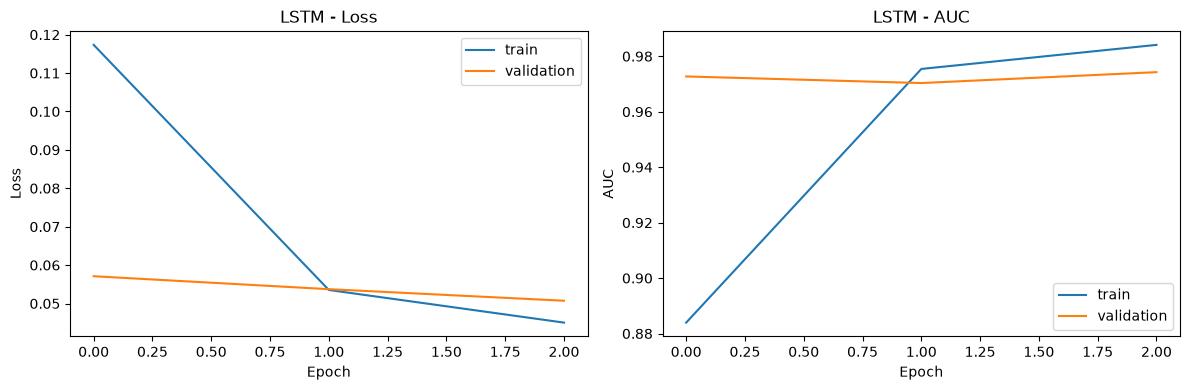

In [25]:
model_LSTM = build_model(
    rnn_type="LSTM",  # LSTM layer: ne è stato usato solo 1 perchè è più stabile, 2 sono più difficili da addetsrare
    bidirectional=False,
    rnn_units=[64],  # n° di neuroni nel layer: è stato usato il valore standard
    pooling=False
)

compile_model(model_LSTM)

model_LSTM.build(input_shape=(None, X_train_pad.shape[1])) # build esplicito per poter visualizzare il summary
model_LSTM.summary()

history_LSTM = train_model(
    model_LSTM,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=3
)

plot_learning_curves(history_LSTM, "LSTM")

**Interpretazione dei risultati**

Durante il training si osserva una rapida **riduzione della loss sia sul training set che sul validation set**, segno che il modello riesce ad apprendere in modo efficace le rappresentazioni testuali già nelle prime epoche.

Parallelamente, la metrica **AUC mostra un miglioramento significativo sul training set**, passando da circa 0.88 a oltre 0.98. **Sul validation set l'AUC si mantiene costantemente elevata** (circa 0.97), con oscillazioni contenute tra le diverse epoche. Questo indica una buona capacità del modello di discriminare tra classi positive e negative indipendentemente dalla soglia di classificazione.

I valori di loss e AUC osservati sul validation set risultano comparabili a quelli ottenuti sul training set, **senza evidenti segnali di overfitting** nelle prime epoche di addestramento.

Il comportamento del modello mostra inoltre una **convergenza rapida**: dopo poche epoche i miglioramenti diventano marginali, indicando che il modello raggiunge velocemente un plateau prestazionale. Questo suggerisce che l’architettura LSTM base sia già in grado di catturare una buona parte dell’informazione utile, ma potrebbe essere limitata nella capacità di modellare dipendenze più complesse nel testo.


### Valutazione del modello LSTM base

In [26]:
# THRESHOLD TUNING sul validation set

y_val_pred = model_LSTM.predict(X_val_pad)

best_thresholds_LSTM = find_best_thresholds(
    y_val.values,
    y_val_pred
)


# VALUTAZIONE FINALE sul test set

results_LSTM = evaluate_model(
    model_LSTM,
    X_test_pad,
    y_test,
    threshold=best_thresholds_LSTM
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step

GLOBAL METRICS
Accuracy (subset): 0.8992
Macro Precision: 0.4654
Macro Recall: 0.6126
Macro F1: 0.5055

F1-score per classe:
toxic: 0.7918
severe_toxic: 0.4566
obscene: 0.7847
threat: 0.0565
insult: 0.7261
identity_hate: 0.2171

Classification report:

               precision    recall  f1-score   support

        toxic       0.76      0.83      0.79      1541
 severe_toxic       0.37      0.60      0.46       167
      obscene       0.77      0.79      0.78       839
       threat       0.03      0.16      0.06        49
       insult       0.72      0.73      0.73       804
identity_hate       0.13      0.56      0.22       118

    micro avg       0.62      0.77      0.69      3518
    macro avg       0.47      0.61      0.51      3518
 weighted avg       0.70      0.77      0.73      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP   

**Interpretazione dei risultati della valutazione**

Il modello LSTM base raggiunge **prestazioni soddisfacenti sulle classi più frequenti** del dataset. Le categorie *toxic, obscene* e *insult* ottengono F1-score compresi tra circa 0.72 e 0.79, dimostrando una buona capacità di riconoscere le forme più comuni di tossicità.

**Le prestazioni risultano invece nettamente inferiori sulle classi rare**. In particolare, *threat* presenta un F1-score di appena 0.06, mentre *identity_hate* raggiunge circa 0.22. Sebbene il threshold tuning aumenti il recall di queste categorie, la precision rimane molto bassa, generando numerosi falsi positivi.

Si osserva inoltre una differenza significativa tra Macro Recall (0.61) e Macro Precision (0.47). Ciò indica che il threshold tuning tende a favorire il recupero degli esempi positivi, aumentando il numero di istanze correttamente individuate ma anche il numero di falsi positivi, soprattutto nelle classi minoritarie.

I risultati ottenuti mostrano che una LSTM unidirezionale è in grado di apprendere efficacemente le caratteristiche associate alle classi più frequenti, ma incontra difficoltà nel modellare le categorie meno rappresentate. Per questo motivo, nel passo successivo viene introdotta una rete Bidirectional LSTM (BiLSTM), che può sfruttare simultaneamente il contesto precedente e successivo all'interno del testo e potenzialmente migliorare la rappresentazione delle classi più rare.

-------------------------------------------------

# 4. Modello BiLSTM

Per migliorare le prestazioni del modello LSTM base, viene introdotta un’architettura Bidirectional LSTM (BiLSTM), insieme ad alcune modifiche strutturali volte a migliorare la capacità di rappresentazione del contesto linguistico:

- **Bidirectional LSTM (BiLSTM)**

Per migliorare la capacità del modello di comprendere il contesto linguistico, è stata utilizzata una Bidirectional Long Short-Term Memory (BiLSTM). A differenza di una LSTM unidirezionale, che elabora la sequenza testuale esclusivamente da sinistra verso destra, una BiLSTM analizza la sequenza in entrambe le direzioni: **Forward**, che legge la sequenza da sinistra verso destra, e **Backward**, che la legge in senso inverso. Le rappresentazioni generate dai due passaggi vengono poi concatenate, consentendo al modello di **considerare contemporaneamente sia il contesto precedente sia quello successivo rispetto a ciascuna parola**. Questo approccio risulta particolarmente efficace nei task di NLP, poiché il significato di un termine può dipendere dall’intera frase e non solo dalle parole precedenti.

- **Architettura con 2 layer BiLSTM**

Il modello utilizza due layer BiLSTM consecutivi, con l’obiettivo di aumentare la capacità rappresentativa della rete e migliorare l’estrazione di pattern linguistici più complessi rispetto a una singola LSTM.

- **GlobalMaxPooling1D**

Dopo i layer ricorrenti viene applicato un layer di GlobalMaxPooling1D, che ha la funzione di comprimere l’intera sequenza in un singolo vettore di feature. Per ciascuna dimensione dell’output delle LSTM, viene selezionato il **valore massimo** lungo la sequenza. In questo modo il modello enfatizza le attivazioni più rilevanti (ad esempio parole fortemente indicative di tossicità), riducendo la dimensionalità e il numero di parametri del modello.

Questo approccio è particolarmente adatto alla classificazione di testi tossici, in quanto permette di catturare la presenza di segnali forti anche quando compaiono solo una volta nel commento, indipendentemente dalla loro posizione.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,540,422 (24.95 MB)

 Trainable params: 6,540,422 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2271s 5s/step - auc: 0.8674 - loss: 0.1229 - val_auc: 0.9713 - val_loss: 0.0572
Epoch 2/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2462s 5s/step - auc: 0.9747 - loss: 0.0537 - val_auc: 0.9775 - val_loss: 0.0510
Epoch 3/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 9508s 19s/step - auc: 0.9805 - loss: 0.0478 - val_auc: 0.9786 - val_loss: 0.0506


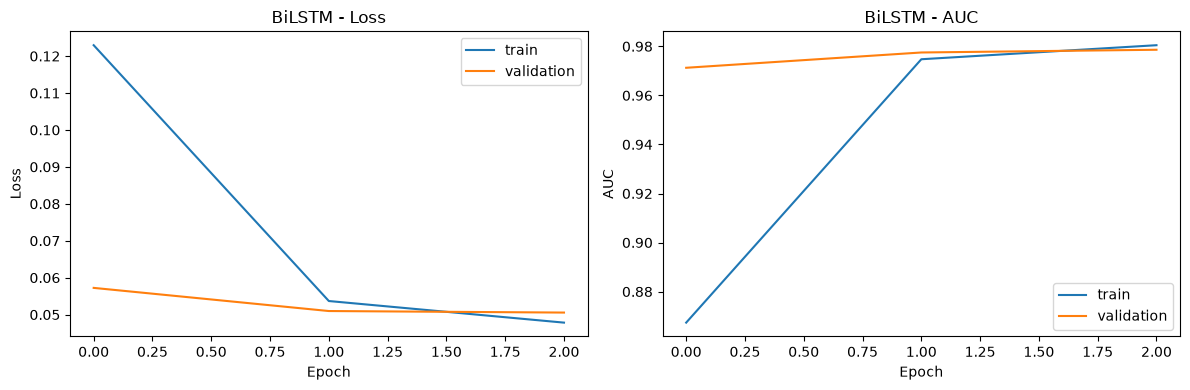

In [27]:
clear_session()

model_BiLSTM = build_model(
    rnn_type="LSTM",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True
)

compile_model(model_BiLSTM)

model_BiLSTM.build(input_shape=(None, X_train_pad.shape[1]))
model_BiLSTM.summary()

history_BiLSTM = train_model(
    model_BiLSTM,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=3
)

plot_learning_curves(history_BiLSTM, "BiLSTM")

**Interpretazione dei risultati**

Durante il training si osserva una rapida **riduzione della loss sia sul training set che sul validation set**, molto simile a quanto osservato nel modello LSTM base. La loss passa da circa 0.123 a 0.048 sul training set e da 0.057 a circa 0.051 sul validation set, indicando che il modello apprende efficacemente le rappresentazioni testuali.

Parallelamente, la metrica **AUC aumenta in modo significativo sul training set**, passando da circa 0.87 a circa 0.98. **Sul validation set l'AUC raggiunge rapidamente valori molto elevati** (circa 0.97-0.98) e rimane stabile nelle epoche successive. Questo comportamento suggerisce una buona capacità discriminativa del modello anche in presenza di classi fortemente sbilanciate.

I valori di loss e AUC osservati sul validation set risultano molto vicini a quelli ottenuti sul training set, **senza evidenti segnali di overfitting** nelle prime epoche di addestramento.

Rispetto alla LSTM base, l'architettura BiLSTM introduce una maggiore capacità rappresentativa grazie all'elaborazione bidirezionale della sequenza e alla presenza di due layer ricorrenti. Tuttavia, i miglioramenti osservati durante il training risultano contenuti. Anche in questo caso il modello raggiunge rapidamente un plateau prestazionale dopo poche epoche, suggerendo che l'aumento della complessità architetturale non si traduce automaticamente in un miglioramento sostanziale delle prestazioni.

È inoltre importante osservare che il costo computazionale aumenta in modo significativo rispetto alla LSTM base. Sebbene il numero totale di parametri cresca solo moderatamente (da circa 6.45 a 6.54 milioni), il tempo di addestramento risulta notevolmente superiore a causa della doppia elaborazione forward e backward effettuata dai layer bidirezionali.

### **Valutazione del modello BiLSTM**

In [28]:
# THRESHOLD tuning
y_val_pred_BiLSTM = model_BiLSTM.predict(X_val_pad)

best_thresholds_BiLSTM = find_best_thresholds(
    y_val.values,
    y_val_pred_BiLSTM
)

# VALUTAZIONE FINALE
results_BiLSTM = evaluate_model(
    model_BiLSTM,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiLSTM
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 74s 143ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 69s 139ms/step

GLOBAL METRICS
Accuracy (subset): 0.9021
Macro Precision: 0.4684
Macro Recall: 0.6160
Macro F1: 0.5063

F1-score per classe:
toxic: 0.7858
severe_toxic: 0.4791
obscene: 0.7925
threat: 0.0324
insult: 0.7299
identity_hate: 0.2184

Classification report:

               precision    recall  f1-score   support

        toxic       0.80      0.78      0.79      1541
 severe_toxic       0.39      0.62      0.48       167
      obscene       0.76      0.83      0.79       839
       threat       0.02      0.08      0.03        49
       insult       0.71      0.75      0.73       804
identity_hate       0.13      0.64      0.22       118

    micro avg       0.62      0.76      0.68      3518
    macro avg       0.47      0.62      0.51      3518
 weighted avg       0.72      0.76      0.73      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione dei risultati della valutazione**

Il modello BiLSTM ottiene prestazioni complessivamente molto simili a quelle della LSTM base. Il Macro F1-score passa da circa 0.505 a 0.506, evidenziando un miglioramento estremamente contenuto nonostante l'aumento della complessità del modello.

Le classi più frequenti continuano a essere quelle meglio riconosciute. In particolare:
- *toxic*: F1 ≈ 0.79
- *obscene*: F1 ≈ 0.79
- *insult*: F1 ≈ 0.73

Questi valori risultano sostanzialmente allineati a quelli ottenuti dalla LSTM base.

Si osserva invece un lieve miglioramento nella classe *severe_toxic*, che passa da circa 0.46 a circa 0.48 di F1-score. Questo suggerisce che il contesto bidirezionale possa fornire informazioni aggiuntive utili per riconoscere forme più severe di linguaggio offensivo.

Le classi maggiormente problematiche rimangono tuttavia threat e identity_hate:
- *threat*: F1 ≈ 0.03
- *identity_hate*: F1 ≈ 0.22

In particolare, la classe threat peggiora rispetto alla LSTM base, confermando la difficoltà del modello nel riconoscere categorie estremamente rare e scarsamente rappresentate nel dataset.

Anche in questo caso si osserva una differenza marcata tra **Macro Recall (0.62)** e **Macro Precision (0.47)**. Il threshold tuning continua quindi a privilegiare il recupero degli esempi positivi, aumentando il recall delle classi rare ma generando un numero elevato di falsi positivi.

Nel complesso, i risultati mostrano che l'introduzione della bidirezionalità e di un secondo layer LSTM non produce miglioramenti sostanziali sulle metriche finali. Sebbene il modello riesca a sfruttare il contesto sia precedente sia successivo all'interno della sequenza, il problema dello sbilanciamento delle classi continua a rappresentare il principale limite delle prestazioni.

Per questo motivo, nel passo successivo viene mantenuta l'architettura BiLSTM ma viene introdotta una Binary Focal Crossentropy, una funzione di loss progettata specificamente per concentrare l'apprendimento sugli esempi più difficili e sulle classi minoritarie, con l'obiettivo di migliorare le prestazioni sulle categorie meno rappresentate del dataset.

--------------------------

# 5. Modello BiLSTM con Focal Loss

La gestione del class imbalance rappresenta uno dei problemi principali nei task di classificazione testuale multi-label, in particolare quando si lavora con dataset fortemente sbilanciati come quello delle toxic comments.

Per affrontare questo problema, nel progetto sono state adottate due strategie complementari: 
- **Threshold tuning per singola classe** (già utilizzato nei modelli precedenti), che consiste nell’ottimizzare la soglia decisionale per ciascuna etichetta sul validation set al fine di massimizzare l’F1-score per classe;
- **Binary Focal Crossentropy**,come funzione di loss alternativa alla binary crossentropy standard.

La Binary Focal Crossentropy è una funzione di costo progettata specificamente per problemi di classificazione sbilanciata. A differenza della binary crossentropy tradizionale, essa introduce un meccanismo di pesatura dinamica degli errori: riduce il contributo degli esempi facili (già correttamente classificati con alta confidenza) e aumenta l’importanza degli esempi difficili, che spesso appartengono alle classi minoritarie.

Questo comportamento è particolarmente utile nei problemi multi-label, dove ogni istanza può appartenere contemporaneamente a più categorie. In questo caso, il problema viene trattato come una serie di classificazioni binarie indipendenti, una per ciascuna classe.

La focal loss è controllata da due parametri principali:
- gamma (γ), che regola la focalizzazione sugli esempi difficili;
- alpha (α), che bilancia il peso tra classi positive e negative.

**Fonte:** https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryFocalCrossentropy

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,540,422 (24.95 MB)

 Trainable params: 6,540,422 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2191s 4s/step - auc: 0.9204 - loss: 0.0277 - val_auc: 0.9808 - val_loss: 0.0146
Epoch 2/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2286s 5s/step - auc: 0.9849 - loss: 0.0134 - val_auc: 0.9854 - val_loss: 0.0131
Epoch 3/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2392s 5s/step - auc: 0.9902 - loss: 0.0114 - val_auc: 0.9850 - val_loss: 0.0133


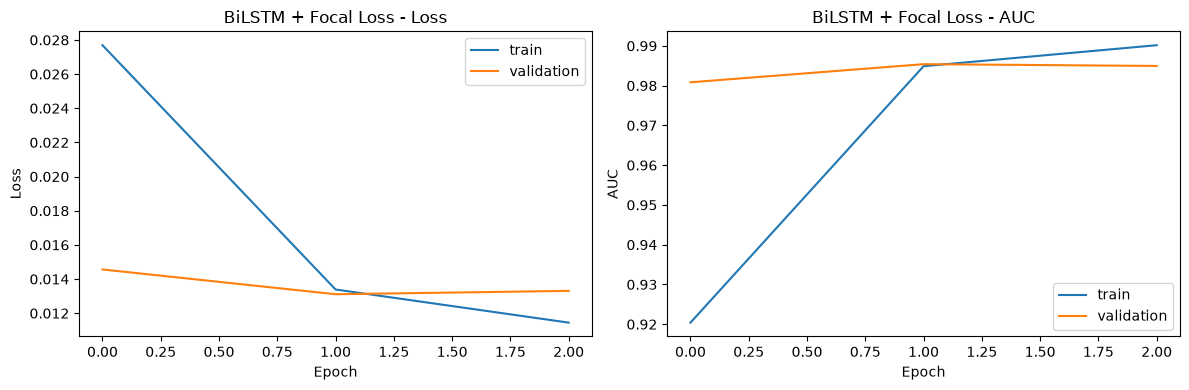

In [25]:
clear_session()

model_BiLSTM_focal_loss = build_model(
    rnn_type="LSTM",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True
)

model_BiLSTM_focal_loss.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=False,
        alpha=0.25,
        gamma=2.0,
        from_logits=False
    ),
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

model_BiLSTM_focal_loss.build(input_shape=(None, X_train_pad.shape[1]))
model_BiLSTM_focal_loss.summary()

history_BiLSTM_focal_loss = train_model(
    model_BiLSTM_focal_loss,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=3
)

plot_learning_curves(history_BiLSTM_focal_loss, "BiLSTM + Focal Loss")

**Interpretazione dei risultati**

L’introduzione della **Binary Focal Crossentropy** produce un **miglioramento significativo** rispetto ai modelli precedenti, sia in termini di performance globali che di bilanciamento tra le classi.

Durante il training si osserva una **rapida riduzione della loss**, che passa da circa 0.027 a 0.011 sul training set, mentre sul validation set si mantiene stabile attorno a valori molto bassi (≈ 0.013). Parallelamente, la metrica **AUC** cresce rapidamente fino a valori prossimi a **0.99 sul training set** e si stabilizza intorno a **0.98–0.985 sul validation set**. Questo indica una forte capacità discriminativa del modello e una buona stabilità del processo di apprendimento.

Rispetto ai modelli precedenti (LSTM e BiLSTM con Binary Crossentropy), si osserva un miglioramento netto delle metriche di training e validation, in particolare una maggiore separazione tra classi positive e negative già nelle prime epoche. Il modello converge rapidamente e raggiunge prestazioni elevate già entro la seconda epoca.

### **Valutazione del modello BiLSTM con Focal Loss**

In [26]:
# THRESHOLD TUNING
y_val_pred_focal_loss = model_BiLSTM_focal_loss.predict(X_val_pad)

best_thresholds_BiLSTM_focal_loss = find_best_thresholds(
    y_val.values,
    y_val_pred_focal_loss
)

# VALUTAZIONE FINALE
results_BiLSTM_focal_loss = evaluate_model(
    model_BiLSTM_focal_loss,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiLSTM_focal_loss
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 65s 127ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step

GLOBAL METRICS
Accuracy (subset): 0.9130
Macro Precision: 0.5040
Macro Recall: 0.6052
Macro F1: 0.5374

F1-score per classe:
toxic: 0.8063
severe_toxic: 0.5183
obscene: 0.8036
threat: 0.1272
insult: 0.7278
identity_hate: 0.2415

Classification report:

               precision    recall  f1-score   support

        toxic       0.83      0.78      0.81      1541
 severe_toxic       0.49      0.55      0.52       167
      obscene       0.76      0.85      0.80       839
       threat       0.09      0.22      0.13        49
       insult       0.69      0.77      0.73       804
identity_hate       0.17      0.45      0.24       118

    micro avg       0.69      0.77      0.72      3518
    macro avg       0.50      0.61      0.54      3518
 weighted avg       0.73      0.77      0.75      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione dei risultati della valutazione**

Questo modello -con introduzione della **Binary Focal Crossentropy**- mostra un miglioramento consistente rispetto ai modelli precedenti anche nelle metriche di test.

Il **Macro F1-scor** aumenta da circa 0.50–0.51 (LSTM e BiLSTM standard) a circa 0.54, indicando un miglior equilibrio complessivo tra le classi. In particolare, si osserva un **miglioramento significativo nelle classi minoritarie**, che rappresentavano il principale limite dei modelli precedenti.

Le classi più frequenti continuano a ottenere prestazioni elevate, con valori che risultano leggermente superiori o comunque stabili rispetto ai modelli LSTM e BiLSTM standard, confermando che la focal loss non degrada le performance sulle classi maggioritarie:
- *toxic*: F1 ≈ 0.81
- *obscene*: F1 ≈ 0.80
- *insult*: F1 ≈ 0.73

Il miglioramento più rilevante riguarda invece le classi rare, indicando che la Focal Loss riesce effettivamente a migliorare l’apprendimento delle classi minoritarie, riducendo l’effetto dominante delle classi più frequenti:
- *severe_toxic*: F1 passa a ≈ 0.52 (rispetto a ~0.46–0.48 nei modelli precedenti)
- *threat*: F1 cresce fino a ≈ 0.13 (precedentemente ~0.03–0.06)
- *identity_hate*: F1 aumenta fino a ≈ 0.24 (precedentemente ~0.21–0.22)

Si osserva inoltre un **incremento del Macro Recall** (≈ 0.61) rispetto ai modelli precedenti, mantenendo un **Macro Precision stabile** (~0.50). Questo suggerisce che il modello è più efficace nel recuperare esempi positivi delle classi rare, senza introdurre un degrado significativo nella precision.

La differenza tra precision e recall rimane comunque presente, ma risulta più bilanciata rispetto a LSTM e BiLSTM standard, indicando un miglior compromesso tra falsi positivi e falsi negativi.


In conclusione, nel complesso il modello BiLSTM con Focal Loss rappresenta il miglior modello tra quelli finora testati, con: miglioramento del Macro F1, miglioramento significativo delle classi rare, maggiore stabilità tra training e validation, migliore capacità di gestione dello sbilanciamento.

La combinazione di architettura bidirezionale + focal loss si dimostra quindi particolarmente efficace per questo task, confermando che il principale limite dei modelli precedenti non era la capacità rappresentativa della rete, ma la gestione dello sbilanciamento delle classi.

-------------------------

# 6. Modello BiLSTM con Focal Loss + LR Scheduler

Il modello mantiene la stessa architettura del BiLSTM con due layer ricorrenti bidirezionali, il pooling globale, e la funzione di loss Binary Focal Crossentropy già utilizzata nei modelli precedenti per la gestione dello sbilanciamento delle classi.

Per migliorare ulteriormente la stabilità e la capacità di convergenza del modello BiLSTM, viene introdotta una strategia di ottimizzazione del learning rate basata su **Learning Rate Scheduler**.

Il Learning Rate Scheduler è una tecnica che modifica dinamicamente il valore del learning rate durante l’addestramento. In questo caso viene utilizzato uno schema di tipo step decay, definito come segue:
- il learning rate iniziale viene impostato a 1e-3 (10⁻³);
- ogni 15 epoche, il learning rate viene dimezzato;
- questo processo continua per tutta la durata dell’addestramento (20 epoche).

L’idea alla base di questa strategia è combinare due fasi complementari:
- nelle prime epoche, un learning rate più alto permette un apprendimento rapido e una convergenza veloce verso regioni promettenti dello spazio dei parametri;
- nelle epoche successive, la riduzione progressiva del learning rate consente aggiornamenti più piccoli e stabili, migliorando la capacità del modello di rifinire la soluzione ed evitare oscillazioni.

Questa tecnica è particolarmente utile nei modelli deep learning con architetture ricorrenti, dove una fase iniziale di esplorazione seguita da una fase di raffinamento può portare a migliori prestazioni e maggiore stabilità.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,540,422 (24.95 MB)

 Trainable params: 6,540,422 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2128s 4s/step - auc: 0.9236 - loss: 0.0277 - val_auc: 0.9828 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 2/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2425s 5s/step - auc: 0.9850 - loss: 0.0134 - val_auc: 0.9857 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 3/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2506s 5s/step - auc: 0.9895 - loss: 0.0118 - val_auc: 0.9851 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 4/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2513s 5s/step - auc: 0.9918 - loss: 0.0107 - val_auc: 0.9851 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 5/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2510s 5s/step - auc: 0.9936 - loss: 0.0097 - val_auc: 0.9830 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 6/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2511s 5s/step - auc: 0.9950 - loss: 0.0087 - val_auc: 0.9822 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 7/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2559s 5s/step - auc: 0.9958 - loss: 0.0080 - val_auc: 0.9797 - val_loss: 0.0171 - learning_rate:

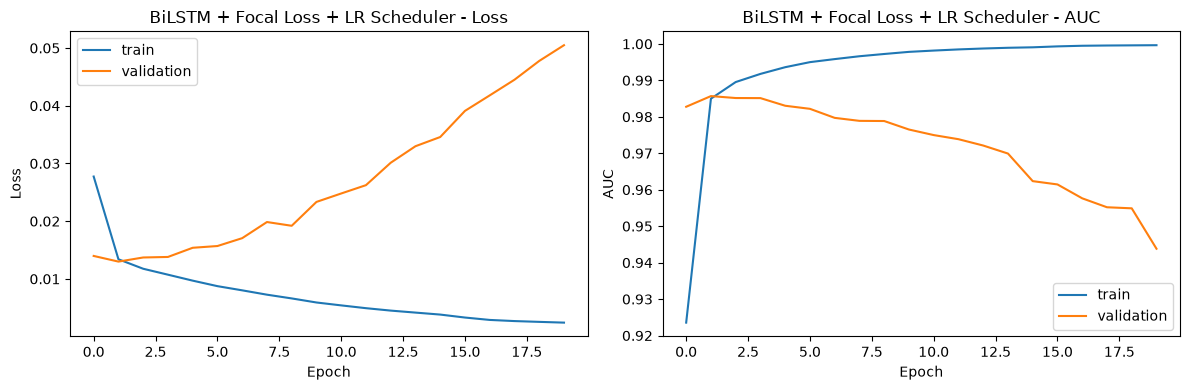

In [25]:
clear_session()

model_BiLSTM_lr_scheduler = build_model(
    rnn_type="LSTM",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True
)

model_BiLSTM_lr_scheduler.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # valore iniziale di learning rate
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        alpha=0.25,
        gamma=2.0
    ),
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

model_BiLSTM_lr_scheduler.build(input_shape=(None, X_train_pad.shape[1]))
model_BiLSTM_lr_scheduler.summary()

history_BiLSTM_lr_scheduler = train_model(
    model_BiLSTM_lr_scheduler,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=20,
    batch_size=256,
    use_lr_scheduler=True,
)

plot_learning_curves(history_BiLSTM_lr_scheduler, "BiLSTM + Focal Loss + LR Scheduler")

**Interpretazione dei risultati**

Durante il training si osserva una riduzione continua della loss sul training set, che passa da circa 0.028 a 0.002, accompagnata da un incremento costante dell'AUC fino a valori prossimi a 1.00. Questo comportamento indica che il modello continua a migliorare la propria capacità di adattarsi ai dati di addestramento per tutta la durata delle 20 epoche.

Sul validation set, tuttavia, il comportamento è differente. Nelle prime epoche si osservano i migliori risultati, con una loss minima pari a circa 0.013 e un'AUC prossima a 0.986 già tra la seconda e la terza epoca. Successivamente, mentre le prestazioni sul training set continuano a migliorare, la validation loss aumenta progressivamente e la validation AUC diminuisce gradualmente fino a circa 0.944 nell'ultima epoca.

Questo andamento evidenzia la comparsa di un fenomeno di overfitting. Il modello continua infatti ad apprendere dettagli specifici del training set senza ottenere benefici sulla capacità di generalizzazione. È interessante osservare che la riduzione del learning rate alla quindicesima epoca non riesce a invertire questa tendenza: pur rendendo gli aggiornamenti dei pesi più piccoli e stabili, il modello continua a sovra-adattarsi ai dati di addestramento.

Rispetto al modello BiLSTM con Focal Loss addestrato per sole 3 epoche, l'estensione dell'addestramento a 20 epoche consente comunque al modello di esplorare regioni differenti dello spazio dei parametri e di migliorare la rappresentazione delle classi meno frequenti. Tuttavia, le curve di apprendimento suggeriscono che il punto ottimale di generalizzazione venga raggiunto molto prima del termine dell'addestramento.

Nel complesso, il Learning Rate Scheduler contribuisce a rendere più graduale la fase finale dell'ottimizzazione, ma non è sufficiente da solo a prevenire l'overfitting quando il numero di epoche diventa elevato.

### Valutazione

In [26]:
# THRESHOLD TUNING
y_val_pred_lr_scheduler = model_BiLSTM_lr_scheduler.predict(X_val_pad)

best_thresholds_BiLSTM_lr_scheduler = find_best_thresholds(
    y_val.values,
    y_val_pred_lr_scheduler
)

# VALUTAZIONE FINALE
results_BiLSTM_lr_scheduler = evaluate_model(
    model_BiLSTM_lr_scheduler,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiLSTM_lr_scheduler
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 68s 135ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 64s 129ms/step

GLOBAL METRICS
Accuracy (subset): 0.9001
Macro Precision: 0.5162
Macro Recall: 0.6353
Macro F1: 0.5613

F1-score per classe:
toxic: 0.7469
severe_toxic: 0.4867
obscene: 0.7688
threat: 0.3571
insult: 0.6867
identity_hate: 0.3214

Classification report:

               precision    recall  f1-score   support

        toxic       0.72      0.77      0.75      1541
 severe_toxic       0.41      0.60      0.49       167
      obscene       0.77      0.77      0.77       839
       threat       0.27      0.51      0.36        49
       insult       0.68      0.70      0.69       804
identity_hate       0.25      0.46      0.32       118

    micro avg       0.67      0.73      0.70      3518
    macro avg       0.52      0.64      0.56      3518
 weighted avg       0.69      0.73      0.71      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione de irisultati della valutazione**

Il modello BiLSTM con Focal Loss e Learning Rate Scheduler ottiene il miglior risultato complessivo tra tutti i modelli valutati fino a questo punto. Il Macro F1-score raggiunge 0.561, superando sia la LSTM base (0.506), sia la BiLSTM (0.506), sia la BiLSTM con sola Focal Loss (0.537).

Il miglioramento più evidente riguarda le classi minoritarie, che rappresentavano il principale punto debole dei modelli precedenti. In particolare:

threat: F1-score ≈ 0.36 (contro 0.13 del modello BiLSTM con Focal Loss e 0.03 della BiLSTM standard);
identity_hate: F1-score ≈ 0.32 (contro 0.24 del modello precedente e 0.22 della BiLSTM standard).

Questi risultati indicano che la combinazione tra Focal Loss, addestramento più lungo e ottimizzazione del learning rate permette al modello di apprendere meglio le caratteristiche associate alle classi rare, migliorandone significativamente il riconoscimento.

Si osserva inoltre un incremento della Macro Precision (0.52) rispetto ai modelli precedenti, mantenendo contemporaneamente un Macro Recall elevato (0.64). Questo suggerisce un miglior bilanciamento tra recupero degli esempi positivi e contenimento dei falsi positivi.

Le classi più frequenti (toxic, obscene e insult) mantengono prestazioni elevate, pur mostrando una lieve diminuzione dell'F1-score rispetto alla versione BiLSTM con sola Focal Loss. Tale riduzione appare tuttavia contenuta ed è compensata dal notevole miglioramento ottenuto sulle categorie minoritarie.

Analizzando le confusion matrix emerge infatti una sostanziale riduzione dei falsi negativi nelle classi rare, in particolare per threat, dove il numero di veri positivi aumenta da 11 a 25. Questo comportamento conferma che il modello diventa maggiormente sensibile agli esempi appartenenti alle categorie meno rappresentate.

Nel complesso, i risultati mostrano che l'introduzione del Learning Rate Scheduler produce un miglioramento tangibile delle metriche macro, che rappresentano l'obiettivo principale in presenza di dataset fortemente sbilanciati. Nonostante le evidenze di overfitting osservate nelle curve di apprendimento, il modello riesce comunque a ottenere le migliori prestazioni finali sul test set, dimostrando una maggiore efficacia nel riconoscimento delle classi minoritarie rispetto a tutte le configurazioni precedentemente analizzate.



----------------------------

# 7. Modello BiLSTM con EarlyStopping + ReduceLROnPlateau

Questo modello mantiene la stessa architettura BiLSTM utilizzata nei modelli precedenti, composta da due layer LSTM bidirezionali con 64 e 32 unità, seguiti da un layer di Global Max Pooling, da un layer di Dropout e da un layer Dense finale per la classificazione multilabel delle sei categorie di tossicità.

L'obiettivo principale di questa configurazione è ridurre il rischio di **overfitting**, fenomeno che si verifica quando il modello apprende in modo eccessivamente dettagliato le caratteristiche del training set, perdendo capacità di generalizzazione sui dati non osservati.

Per contrastare questo problema sono state introdotte diverse tecniche di regolarizzazione.

- **Dropout**

Il layer di Dropout utilizza un tasso di disattivazione elevato (ad esempio 0.5), che durante l'addestramento disabilita casualmente una parte dei neuroni ad ogni iterazione. Questa strategia impedisce al modello di fare affidamento su specifiche connessioni interne e favorisce l'apprendimento di rappresentazioni più robuste e generalizzabili.

- **Recurrent Dropout**

Nei layer LSTM viene inoltre applicato il Recurrent Dropout, che introduce una regolarizzazione anche sulle connessioni ricorrenti interne della rete. In questo modo si riduce la possibilità che il modello memorizzi schemi troppo specifici presenti nel training set, migliorando la capacità di generalizzazione.

- **Early Stopping**

Per evitare di proseguire l'addestramento oltre il punto di massima capacità di generalizzazione, viene utilizzato il callback Early Stopping.

Questa tecnica monitora la loss sul validation set e interrompe automaticamente il training quando non vengono osservati miglioramenti per un numero prefissato di epoche consecutive (patience). Inoltre, grazie al parametro `restore_best_weights=True`, al termine dell'addestramento vengono ripristinati i pesi corrispondenti all'epoca con le migliori prestazioni di validazione.

L'Early Stopping consente quindi di:

* ridurre l'overfitting;
* diminuire i tempi di addestramento;
* conservare la versione del modello con la migliore capacità di generalizzazione.

- **ReduceLROnPlateau**

In aggiunta viene utilizzato il callback ReduceLROnPlateau, che monitora anch'esso la validation loss.

Quando il miglioramento della metrica si arresta per alcune epoche consecutive, il learning rate viene automaticamente ridotto di un fattore prestabilito. Questa strategia permette al modello di effettuare aggiornamenti più piccoli e controllati nella fase finale dell'addestramento, facilitando la convergenza verso una soluzione più stabile.

L'utilizzo combinato di Early Stopping e ReduceLROnPlateau consente di ottenere un addestramento più efficiente: inizialmente il modello apprende rapidamente grazie a un learning rate relativamente elevato, mentre nelle fasi successive il learning rate viene progressivamente ridotto e l'addestramento viene interrotto non appena le prestazioni sul validation set smettono di migliorare.

Nel complesso, questa configurazione rappresenta una strategia di regolarizzazione più efficace rispetto al semplice Learning Rate Scheduler utilizzato nei modelli precedenti, poiché adatta dinamicamente sia la durata dell'addestramento sia il learning rate in funzione delle prestazioni osservate sul validation set.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,540,422 (24.95 MB)

 Trainable params: 6,540,422 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2568s 5s/step - auc: 0.8962 - loss: 0.0318 - val_auc: 0.9781 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 2/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2483s 5s/step - auc: 0.9792 - loss: 0.0151 - val_auc: 0.9829 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 3/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2495s 5s/step - auc: 0.9856 - loss: 0.0131 - val_auc: 0.9851 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 4/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - auc: 0.9891 - loss: 0.0120
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
499/499 ━━━━━━━━━━━━━━━━━━━━ 2473s 5s/step - auc: 0.9885 - loss: 0.0122 - val_auc: 0.9841 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 5/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - auc: 0.9907 - loss: 0.0111
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
499/499 ━━━━━━━━━━━━━━━━━━━━ 2513s 5s/step - auc: 0.9907 - loss: 0.0112 - val_auc: 0.9851 - val_loss: 0.0134 - learning_rat

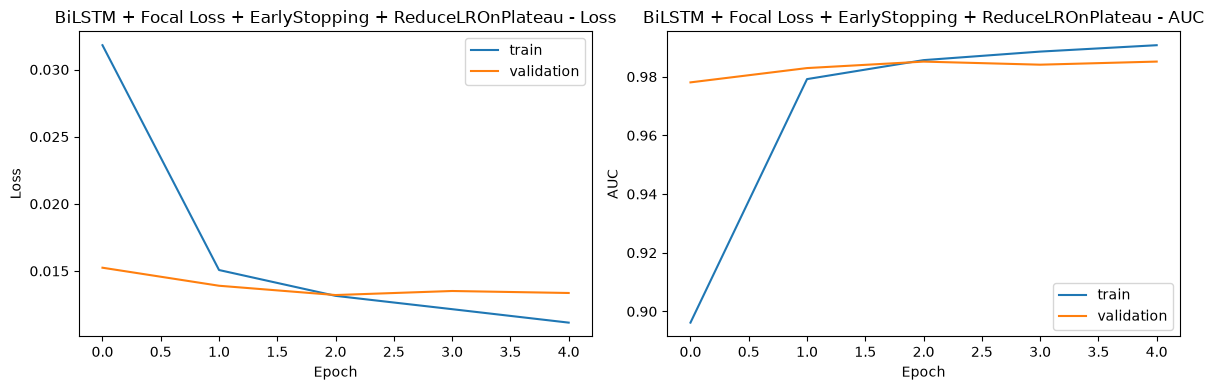

In [29]:
clear_session()

model_BiLSTM_regularized = build_model(
    rnn_type="LSTM",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True,
    dropout_rate=0.5,
    recurrent_dropout_rate=0.3
)

model_BiLSTM_regularized.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        alpha=0.25,
        gamma=2.0
    ),
    metrics=[
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_BiLSTM_regularized.build(
    input_shape=(None, X_train_pad.shape[1])
)

model_BiLSTM_regularized.summary()

history_BiLSTM_regularized = train_model(
    model_BiLSTM_regularized,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=20,
    batch_size=256,
    use_early_stopping=True,
    use_reduce_lr=True,
    early_stopping_patience=2,
    reduce_lr_patience=1
)

plot_learning_curves(
    history_BiLSTM_regularized,
    "BiLSTM + Focal Loss + EarlyStopping + ReduceLROnPlateau"
)

**Interpretazione dei risultati**

L'andamento delle metriche durante l'addestramento mostra che il modello apprende rapidamente già nelle prime epoche. L'AUC sul training set cresce da circa 0.90 a oltre 0.98, mentre la validation loss diminuisce progressivamente fino a raggiungere il valore minimo di 0.0132 alla terza epoca.

A partire dalla quarta epoca non si osservano ulteriori miglioramenti significativi sulle prestazioni di validazione. Di conseguenza, il callback ReduceLROnPlateau interviene riducendo automaticamente il learning rate, mentre Early Stopping interrompe l'addestramento alla quinta epoca e ripristina i pesi corrispondenti alla terza epoca, identificata come quella con le migliori prestazioni sul validation set.

Questo comportamento conferma l'efficacia delle strategie di regolarizzazione introdotte. A differenza dei modelli addestrati per 20 epoche con il solo Learning Rate Scheduler, il modello non continua ad apprendere dopo il punto di massima generalizzazione, evitando la progressiva divergenza tra training e validation performance che rappresenta un tipico segnale di overfitting.

L'addestramento si conclude quindi dopo sole cinque epoche, riducendo significativamente il tempo computazionale e preservando il modello nella configurazione che offre il miglior equilibrio tra capacità di apprendimento e generalizione.




In [30]:
# THRESHOLD TUNING

y_val_pred_BiLSTM_regularized = model_BiLSTM_regularized.predict(X_val_pad)

best_thresholds_BiLSTM_regularized = find_best_thresholds(
    y_val.values,
    y_val_pred_BiLSTM_regularized
)

# VALUTAZIONE FINALE

results_BiLSTM_regularized = evaluate_model(
    model_BiLSTM_regularized,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiLSTM_regularized
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 76s 149ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 72s 145ms/step

GLOBAL METRICS
Accuracy (subset): 0.9094
Macro Precision: 0.4951
Macro Recall: 0.6224
Macro F1: 0.5340

F1-score per classe:
toxic: 0.8090
severe_toxic: 0.5431
obscene: 0.7959
threat: 0.1053
insult: 0.7263
identity_hate: 0.2244

Classification report:

               precision    recall  f1-score   support

        toxic       0.83      0.79      0.81      1541
 severe_toxic       0.47      0.64      0.54       167
      obscene       0.76      0.83      0.80       839
       threat       0.07      0.22      0.11        49
       insult       0.69      0.76      0.73       804
identity_hate       0.15      0.48      0.22       118

    micro avg       0.67      0.77      0.71      3518
    macro avg       0.50      0.62      0.53      3518
 weighted avg       0.73      0.77      0.74      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione dei risultati della valutazione**

Le prestazioni sul test set mostrano una Accuracy subset pari a 0.9094, un Macro Recall di 0.6224 e un Macro F1-score di 0.5340.

Il modello mantiene buone prestazioni sulle classi più rappresentate. In particolare, la clase **toic** raggiunge un F1-score pari a 0.8090, menre **obscne**e **ins t** ottengono rispettivamente 0.7959 e 0.7263. Anche la clase **severe_txic** mostra un miglioramento rispetto a diverse configurazioni precedenti, raggiungendo un F1-score di 0.5431 grazie a un recall particolarmente elevato (0.64).

Le classi minoritarie continuano invece a rappresentare la principale difficoltà del modello. La casse **hreat** registra un F1-score di 0.1053, mntre **identit_hate** raggiunge 0.2244. Sebbene il recall di queste categorie sia relativamente elevato rispetto alla loro numerosità nel dataset, la precisione rimane bassa a causa dell'elevato numero di falsi positivi generati dal classificatore.

Dal punto di vista globale, il modello privilegia il recupero dei casi positivi rispetto alla precisione, come evidenziato dal Macro Recall superiore al Macro Precision. Questa caratteristica è coerente con l'utilizzo della Binary Focal Crossentropy e del threshold tuning, che tendono a favorire l'identificazione delle classi rare.

Un risultato particolarmente interessante riguarda l'efficacia delle tecniche anti-overfitting adottate. Nonostante l'addestramento sia stato interrotto molto prima rispetto ai modelli con Learning Rate Scheduler, le prestazioni finali risultano comparabili. Ciò suggerisce che una parte consistente delle epoche aggiuntive utilizzate nei modelli precedenti non contribuiva realmente a migliorare la capacità di generalizzazione e favoriva invece la memorizzazione dei dati di training.

Nel complesso, il modello BiLSTM con EarlyStopping e ReduceLROnPlateau rappresenta una soluzione più efficiente dal punto di vista dell'addestramento e più robusta rispetto all'overfitting. Pur non risolvendo completamente le difficoltà legate alle classi estremamente sbilanciate, riesce a mantenere prestazioni competitive utilizzando un numero inferiore di epoche e conservando automaticamente la configurazione con le migliori prestazioni di idazione.




---------------------------------------------

# Modelli con GRU

Anche per i modelli basati su GRU si segue la stessa logica adottata nella sperimentazione con le architetture LSTM: i modelli vengono costruiti in modo progressivo, partendo da una configurazione semplice fino ad arrivare a versioni più complesse e regolarizzate.

In particolare, si parte da un modello GRU base con una singola unità ricorrente, per poi introdurre varianti più avanzate come le versioni bidirezionali, l’utilizzo della Focal Loss per la gestione dello sbilanciamento delle classi e, infine, l’integrazione di strategie di ottimizzazione e regolarizzazione come Learning Rate Scheduler, Early Stopping e ReduceLROnPlateau.

Questa progressione consente di valutare in modo controllato l’impatto di ciascuna modifica architetturale e strategica sulle prestazioni del modello, mantenendo una coerenza metodologica con quanto già fatto per i modelli LSTM e permettendo un confronto diretto tra le diverse configurazioni.

# 8. Modello GRU base

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,437,638 (24.56 MB)

 Trainable params: 6,437,638 (24.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 612s 1s/step - auc: 0.9075 - loss: 0.1096 - val_auc: 0.9780 - val_loss: 0.0522
Epoch 2/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - auc: 0.9810 - loss: 0.0488 - val_auc: 0.9798 - val_loss: 0.0482
Epoch 3/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 545s 1s/step - auc: 0.9870 - loss: 0.0421 - val_auc: 0.9736 - val_loss: 0.0499


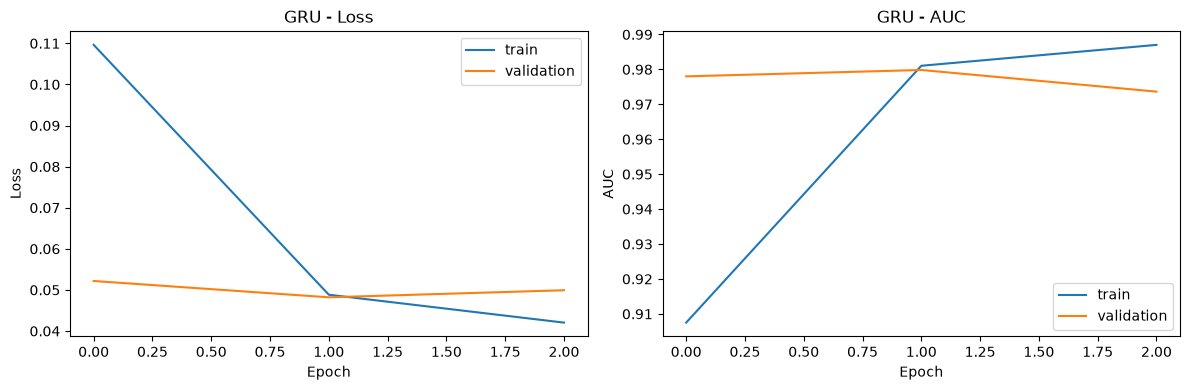

In [27]:
clear_session()

model_GRU = build_model(
    rnn_type="GRU",
    bidirectional=False,
    rnn_units=[64],
    pooling=False
)

compile_model(model_GRU)

model_GRU.build(input_shape=(None, X_train_pad.shape[1]))
model_GRU.summary()

history_GRU = train_model(
    model_GRU,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=3
)

plot_learning_curves(history_GRU, "GRU")

**Interpretazione dei risultati**

Durante le tre epoche di addestramento il modello mostra una rapida convergenza. L'AUC sul training passa da 0.9075 a 0.9870, mentre la loss diminuisce da 0.1096 a 0.0421. Anche sul validation set si osservano prestazioni elevate già dalla prima epoca, con una AUC che raggiunge il valore massimo di 0.9798 alla seconda epoca.

La validation loss diminuisce inizialmente da 0.0522 a 0.0482 per poi aumentare leggermente nell'ultima epoca fino a 0.0499. Analogamente, la validation AUC cala da 0.9798 a 0.9736 tra la seconda e la terza epoca. Questo comportamento suggerisce l'inizio di un lieve fenomeno di overfitting, sebbene ancora contenuto grazie al numero limitato di epoche.

Nel complesso, il modello GRU riesce ad apprendere rapidamente le caratteristiche rilevanti del testo, confermando l'efficienza delle celle GRU nel catturare dipendenze sequenziali con un numero inferiore di parametri rispetto alle LSTM.

In [28]:
# THRESHOLD TUNING

y_val_pred_GRU = model_GRU.predict(X_val_pad)

best_thresholds_GRU = find_best_thresholds(
    y_val.values,
    y_val_pred_GRU
)

# VALUTAZIONE FINALE

results_GRU = evaluate_model(
    model_GRU,
    X_test_pad,
    y_test,
    threshold=best_thresholds_GRU
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step

GLOBAL METRICS
Accuracy (subset): 0.9116
Macro Precision: 0.5028
Macro Recall: 0.6048
Macro F1: 0.5432

F1-score per classe:
toxic: 0.7939
severe_toxic: 0.4885
obscene: 0.7948
threat: 0.1752
insult: 0.7153
identity_hate: 0.2915

Classification report:

               precision    recall  f1-score   support

        toxic       0.81      0.78      0.79      1541
 severe_toxic       0.42      0.57      0.49       167
      obscene       0.76      0.84      0.79       839
       threat       0.14      0.24      0.18        49
       insult       0.67      0.77      0.72       804
identity_hate       0.22      0.42      0.29       118

    micro avg       0.69      0.76      0.72      3518
    macro avg       0.50      0.60      0.54      3518
 weighted avg       0.72      0.76      0.74      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP   

**Interpretazione dei risultati della valutazione**

La valutazione sul test set evidenzia una Accuracy subset pari a 0.9116 e un Macro F1-score di 0.5432.

Le classi più frequenti ottengono risultati molto soddisfacenti:
- *toxic*: F1 = 0.7939
- *obscene*: F1 = 0.7948
- *insult*: F1 = 0.7153

Anche la classe *severe_toxic* raggiunge un risultato discreto (F1 = 0.4885), mentre emergono difficoltà significative sulle categorie più rare:
- *threat*: F1 = 0.1752
- *identity_hate*: F1 = 0.2915

Le confusion matrix mostrano infatti un numero elevato di falsi negativi per queste classi, indice della difficoltà del modello nel riconoscere esempi poco rappresentati nel dataset.

Nel complesso, il modello GRU base raggiunge prestazioni soddisfacenti e dimostra una buona capacità di apprendere le caratteristiche rilevanti del testo. Le migliori prestazioni si osservano sulle classi più frequenti, mentre le categorie minoritarie risultano più difficili da riconoscere a causa dello sbilanciamento del dataset. Il modello rappresenta quindi un valido punto di partenza per valutare l'efficacia di architetture più avanzate.

# 9. Modello BiGRU

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,505,990 (24.82 MB)

 Trainable params: 6,505,990 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2519s 5s/step - auc: 0.8997 - loss: 0.1101 - val_auc: 0.9747 - val_loss: 0.0531
Epoch 2/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2457s 5s/step - auc: 0.9790 - loss: 0.0502 - val_auc: 0.9805 - val_loss: 0.0480
Epoch 3/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2448s 5s/step - auc: 0.9848 - loss: 0.0436 - val_auc: 0.9730 - val_loss: 0.0491


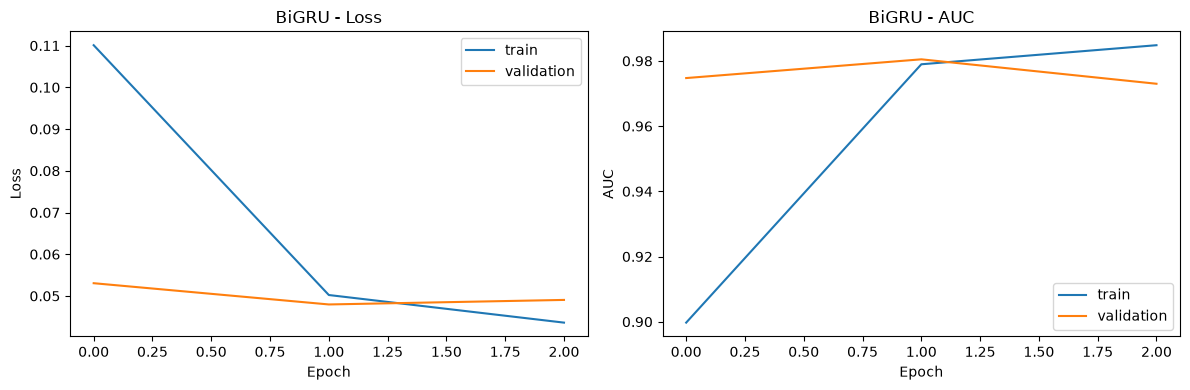

In [29]:
clear_session()

model_BiGRU = build_model(
    rnn_type="GRU",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True
)

compile_model(model_BiGRU)

model_BiGRU.build(input_shape=(None, X_train_pad.shape[1]))
model_BiGRU.summary()

history_BiGRU = train_model(
    model_BiGRU,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=3
)

plot_learning_curves(history_BiGRU, "BiGRU")



**Interpretazione dei risultati**

L'introduzione della bidirezionalità permette al modello di elaborare le sequenze sia in direzione forward che backward, sfruttando il contesto completo del testo.

Durante l'addestramento si osserva un comportamento simile al modello GRU base. L'AUC sul training cresce da 0.8997 a 0.9848, mentre la loss diminuisce da 0.1101 a 0.0436. Sul validation set la AUC raggiunge il valore massimo di 0.9805 alla seconda epoca per poi diminuire leggermente a 0.9730.

Anche in questo caso la validation loss diminuisce inizialmente fino a 0.0480 e successivamente aumenta a 0.0491, indicando l'inizio di un leggero overfitting nelle ultime fasi dell'addestramento.

La presenza di due livelli GRU bidirezionali consente al modello di **catturare relazioni contestuali più complesse** rispetto alla versione unidirezionale, ma comporta un **costo computazionale significativamente maggiore**.

In [30]:
# THRESHOLD TUNING

y_val_pred_BiGRU = model_BiGRU.predict(X_val_pad)

best_thresholds_BiGRU = find_best_thresholds(
    y_val.values,
    y_val_pred_BiGRU
)

# VALUTAZIONE FINALE

results_BiGRU = evaluate_model(
    model_BiGRU,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiGRU
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 58s 115ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step

GLOBAL METRICS
Accuracy (subset): 0.9059
Macro Precision: 0.4899
Macro Recall: 0.6299
Macro F1: 0.5336

F1-score per classe:
toxic: 0.7990
severe_toxic: 0.5047
obscene: 0.8090
threat: 0.1280
insult: 0.7324
identity_hate: 0.2284

Classification report:

               precision    recall  f1-score   support

        toxic       0.80      0.80      0.80      1541
 severe_toxic       0.41      0.65      0.50       167
      obscene       0.79      0.83      0.81       839
       threat       0.11      0.16      0.13        49
       insult       0.69      0.78      0.73       804
identity_hate       0.14      0.56      0.23       118

    micro avg       0.66      0.78      0.72      3518
    macro avg       0.49      0.63      0.53      3518
 weighted avg       0.72      0.78      0.74      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione dei risultati della valutazione**

Sul test set il modello ottiene:
- Accuracy subset = 0.9059
- Macro F1-score = 0.5336

Le prestazioni sulle classi principali risultano leggermente superiori rispetto al GRU base:
- *toxic*: F1 = 0.7990
- *obscene*: F1 = 0.8090
- *insult*: F1 = 0.7324
- *severe_toxic*: F1 = 0.5047

Tuttavia, il miglioramento sulle classi rare non è uniforme. In particolare:
- *identity_hate* presenta un recall molto elevato (0.56), ma una precision ridotta (0.14), segnale di numerosi falsi positivi.
- *threat* rimane la classe più difficile da identificare (F1 = 0.1280).

Nel complesso, la bidirezionalità migliora la capacità di individuare contenuti tossici complessi, ma introduce una maggiore tendenza a generare falsi allarmi sulle categorie minoritarie.

# 10. Modello BiGRU con Focal Loss

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,505,990 (24.82 MB)

 Trainable params: 6,505,990 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2678s 5s/step - auc: 0.9280 - loss: 0.0270 - val_auc: 0.9839 - val_loss: 0.0137
Epoch 2/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2687s 5s/step - auc: 0.9854 - loss: 0.0132 - val_auc: 0.9858 - val_loss: 0.0130
Epoch 3/3
499/499 ━━━━━━━━━━━━━━━━━━━━ 2699s 5s/step - auc: 0.9911 - loss: 0.0110 - val_auc: 0.9851 - val_loss: 0.0135


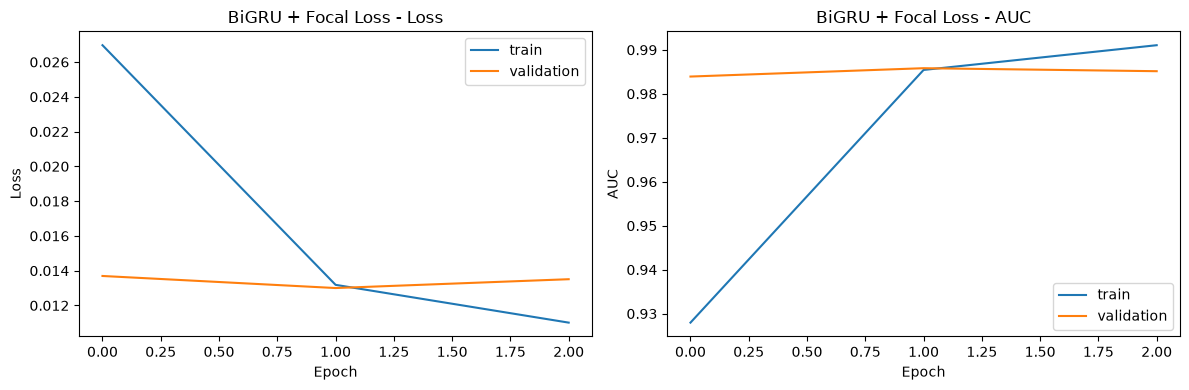

In [31]:
clear_session()

model_BiGRU_focal_loss = build_model(
    rnn_type="GRU",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True
)

model_BiGRU_focal_loss.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=False,
        alpha=0.25,
        gamma=2.0,
        from_logits=False
    ),
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

model_BiGRU_focal_loss.build(input_shape=(None, X_train_pad.shape[1]))
model_BiGRU_focal_loss.summary()

history_BiGRU_focal_loss = train_model(
    model_BiGRU_focal_loss,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=3
)

plot_learning_curves(
    history_BiGRU_focal_loss,
    "BiGRU + Focal Loss"
)



**Interpretazione dei risultati**

In questo modello viene introdotta la Binary Focal Crossentropy per affrontare direttamente il problema dello sbilanciamento delle classi.

L'addestramento mostra una convergenza molto rapida:
- Training AUC da 0.9280 a 0.9911
- Validation AUC stabile intorno a 0.985
- Validation loss molto contenuta (circa 0.013)

Le curve di training e validation risultano particolarmente stabili durante le tre epoche, senza evidenti segnali di overfitting. La Focal Loss concentra maggiormente l'apprendimento sugli esempi difficili e sulle classi meno rappresentate, riducendo l'impatto degli esempi facilmente classificabili.

In [32]:
# THRESHOLD TUNING

y_val_pred_BiGRU_focal_loss = model_BiGRU_focal_loss.predict(X_val_pad)

best_thresholds_BiGRU_focal_loss = find_best_thresholds(
    y_val.values,
    y_val_pred_BiGRU_focal_loss
)

# VALUTAZIONE FINALE

results_BiGRU_focal_loss = evaluate_model(
    model_BiGRU_focal_loss,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiGRU_focal_loss
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 57s 112ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step

GLOBAL METRICS
Accuracy (subset): 0.9187
Macro Precision: 0.5475
Macro Recall: 0.6055
Macro F1: 0.5695

F1-score per classe:
toxic: 0.8034
severe_toxic: 0.5134
obscene: 0.7959
threat: 0.1899
insult: 0.7444
identity_hate: 0.3698

Classification report:

               precision    recall  f1-score   support

        toxic       0.84      0.77      0.80      1541
 severe_toxic       0.51      0.51      0.51       167
      obscene       0.76      0.84      0.80       839
       threat       0.14      0.31      0.19        49
       insult       0.70      0.79      0.74       804
identity_hate       0.33      0.42      0.37       118

    micro avg       0.73      0.76      0.74      3518
    macro avg       0.55      0.61      0.57      3518
 weighted avg       0.75      0.76      0.75      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione dei risultati della valutazione**

Il modello raggiunge i migliori risultati tra le configurazioni GRU addestrate per sole tre epoche:
- Accuracy subset = 0.9187
- Macro Precision = 0.5475
- Macro Recall = 0.6055
- Macro F1-score = 0.5695

Le classi principali mantengono prestazioni elevate:
- *toxic*: F1 = 0.8034
- *obscene*: F1 = 0.7959
- *insult*: F1 = 0.7444

Si osservano inoltre miglioramenti sulle classi minoritarie:
- *identity_hate*: F1 = 0.3698
- *threat*: F1 = 0.1899

Rispetto al BiGRU standard, la Focal Loss migliora il bilanciamento tra precision e recall, aumentando la capacità del modello di riconoscere esempi appartenenti alle classi meno frequenti senza compromettere le prestazioni globali.

Nel complesso, questo modello rappresenta il miglior compromesso tra accuratezza generale e capacità di rilevare le categorie tossiche più rare.

# 11. Modello BiGRU con Focal Loss + LR Scheduler

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,505,990 (24.82 MB)

 Trainable params: 6,505,990 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2497s 5s/step - auc: 0.9282 - loss: 0.0275 - val_auc: 0.9821 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 2/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2301s 5s/step - auc: 0.9862 - loss: 0.0130 - val_auc: 0.9852 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 3/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2312s 5s/step - auc: 0.9912 - loss: 0.0110 - val_auc: 0.9853 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 4/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2328s 5s/step - auc: 0.9939 - loss: 0.0095 - val_auc: 0.9835 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 5/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2331s 5s/step - auc: 0.9954 - loss: 0.0084 - val_auc: 0.9817 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 6/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2307s 5s/step - auc: 0.9964 - loss: 0.0075 - val_auc: 0.9799 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 7/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2317s 5s/step - auc: 0.9971 - loss: 0.0067 - val_auc: 0.9793 - val_loss: 0.0208 - learning_rate:

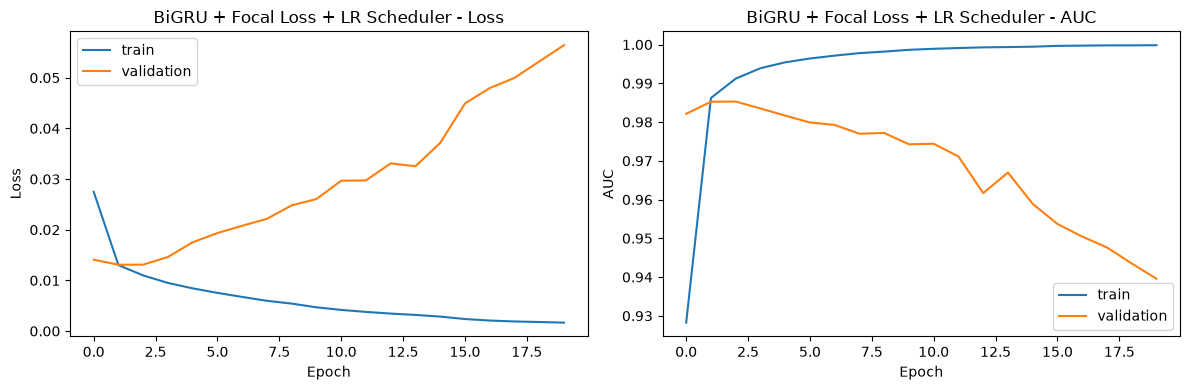

In [27]:
clear_session()

model_BiGRU_lr_scheduler = build_model(
    rnn_type="GRU",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True
)

model_BiGRU_lr_scheduler.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # valore iniziale di learning rate
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        alpha=0.25,
        gamma=2.0
    ),
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

model_BiGRU_lr_scheduler.build(input_shape=(None, X_train_pad.shape[1]))
model_BiGRU_lr_scheduler.summary()

history_BiGRU_lr_scheduler = train_model(
    model_BiGRU_lr_scheduler,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=20,
    batch_size=256,
    use_lr_scheduler=True
)

plot_learning_curves(history_BiGRU_lr_scheduler, "BiGRU + Focal Loss + LR Scheduler")

**Interpretazione dei risultati**

Questo modello combina tre strategie: architettura BiGRU bidirezionale, Binary Focal Crossentropy, e Learning Rate Scheduler con riduzione del learning rate ogni 15 epoche.

L'addestramento evidenzia una crescita continua delle prestazioni sul training set:
- Training AUC da 0.9282 a 0.9998;
- Loss da 0.0275 a 0.0017.

Sul validation set, invece, si osserva un comportamento differente. La validation AUC raggiunge il valore massimo già nelle prime epoche (0.9853 alla terza epoca) e successivamente diminuisce progressivamente fino a 0.9396. Parallelamente, la validation loss cresce da 0.0131 a 0.0564.

Questi risultati mostrano un evidente fenomeno di overfitting. Sebbene il Learning Rate Scheduler riduca il learning rate da 10⁻³ a 5×10⁻⁴ alla sedicesima epoca, la riduzione avviene quando il modello ha già iniziato a memorizzare eccessivamente il training set.

Di conseguenza, il learning rate più basso non riesce a migliorare la generalizzazione, ma contribuisce principalmente a perfezionare ulteriormente l'adattamento ai dati di addestramento.

In [28]:
# THRESHOLD TUNING
y_val_pred_BiGRU_lr_scheduler = model_BiGRU_lr_scheduler.predict(X_val_pad)

best_thresholds_BiGRU_lr_scheduler = find_best_thresholds(
    y_val.values,
    y_val_pred_BiGRU_lr_scheduler
)

# VALUTAZIONE
results_BiGRU_lr_scheduler = evaluate_model(
    model_BiGRU_lr_scheduler,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiGRU_lr_scheduler
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 64s 125ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step

GLOBAL METRICS
Accuracy (subset): 0.9017
Macro Precision: 0.6028
Macro Recall: 0.5842
Macro F1: 0.5767

F1-score per classe:
toxic: 0.7472
severe_toxic: 0.4874
obscene: 0.7686
threat: 0.3824
insult: 0.6765
identity_hate: 0.3984

Classification report:

               precision    recall  f1-score   support

        toxic       0.73      0.77      0.75      1541
 severe_toxic       0.46      0.52      0.49       167
      obscene       0.73      0.81      0.77       839
       threat       0.68      0.27      0.38        49
       insult       0.64      0.72      0.68       804
identity_hate       0.38      0.42      0.40       118

    micro avg       0.68      0.74      0.71      3518
    macro avg       0.60      0.58      0.58      3518
 weighted avg       0.68      0.74      0.71      3518
  samples avg       0.07      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione dei risultati della valutazione**

La valutazione finale mostra:
- Accuracy subset = 0.9017
- Macro Precision = 0.6028
- Macro Recall = 0.5842
- Macro F1-score = 0.5767

Il Macro F1 risulta il migliore tra tutti i modelli GRU analizzati, grazie soprattutto al miglioramento delle classi più rare:
- threat: F1 = 0.3824
- identity_hate: F1 = 0.3984

In particolare, la precision della classe threat raggiunge 0.68, valore nettamente superiore rispetto ai modelli precedenti, indicando una riduzione significativa dei falsi positivi.

Tuttavia, il miglioramento delle classi minoritarie è ottenuto a fronte di un leggero peggioramento delle prestazioni sulle categorie più frequenti:
- toxic: F1 = 0.7472
- obscene: F1 = 0.7686
- insult: F1 = 0.6765

Nel complesso, il modello dimostra che la combinazione tra Focal Loss e Learning Rate Scheduler può favorire il riconoscimento delle classi più rare, ma l'addestramento prolungato introduce un marcato overfitting. I risultati suggeriscono che una strategia di Early Stopping o una riduzione del numero di epoche avrebbe probabilmente consentito di ottenere prestazioni ancora migliori e una maggiore capacità di generalizzazione.

# 12. Modello BiGRU con EarlyStopping + ReduceLROnPlateau

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 64)        │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,505,990 (24.82 MB)

 Trainable params: 6,505,990 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 1991s 4s/step - auc: 0.9186 - loss: 0.0282 - val_auc: 0.9793 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 2/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 1938s 4s/step - auc: 0.9809 - loss: 0.0148 - val_auc: 0.9845 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 3/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 1928s 4s/step - auc: 0.9870 - loss: 0.0128 - val_auc: 0.9852 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 4/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - auc: 0.9894 - loss: 0.0118
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
499/499 ━━━━━━━━━━━━━━━━━━━━ 1930s 4s/step - auc: 0.9896 - loss: 0.0118 - val_auc: 0.9849 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 5/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - auc: 0.9917 - loss: 0.0108
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
499/499 ━━━━━━━━━━━━━━━━━━━━ 1903s 4s/step - auc: 0.9920 - loss: 0.0106 - val_auc: 0.9852 - val_loss: 0.0137 - learning_rat

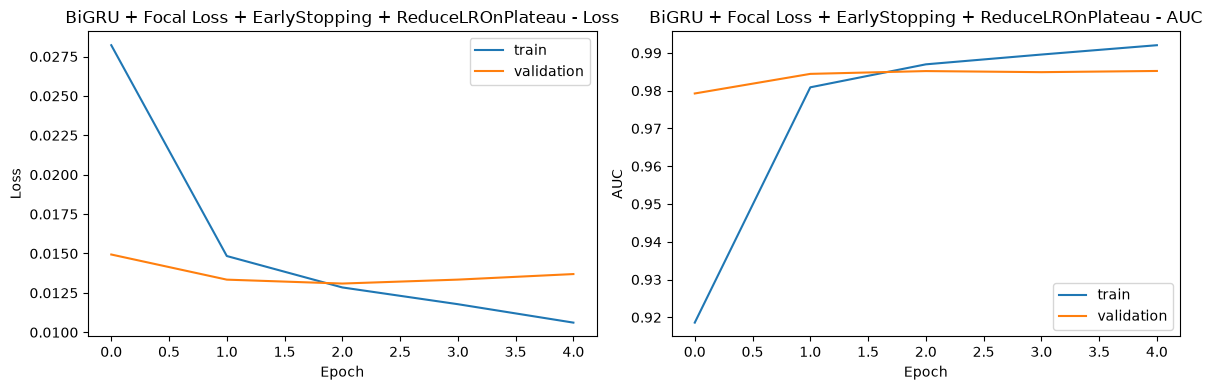

In [31]:
clear_session()

model_BiGRU_regularized = build_model(
    rnn_type="GRU",
    bidirectional=True,
    rnn_units=[64, 32],
    pooling=True,
    dropout_rate=0.5,
    recurrent_dropout_rate=0.3
)

model_BiGRU_regularized.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        alpha=0.25,
        gamma=2.0
    ),
    metrics=[
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_BiGRU_regularized.build(
    input_shape=(None, X_train_pad.shape[1])
)

model_BiGRU_regularized.summary()

history_BiGRU_regularized = train_model(
    model_BiGRU_regularized,
    X_train_pad,
    y_train,
    X_val_pad,
    y_val,
    epochs=20,
    batch_size=256,
    use_early_stopping=True,
    use_reduce_lr=True,
    early_stopping_patience=2,
    reduce_lr_patience=1
)

plot_learning_curves(
    history_BiGRU_regularized,
    "BiGRU + Focal Loss + EarlyStopping + ReduceLROnPlateau"
)

**Interpretazione dei risultati**

Anche per il modello BiGRU con EarlyStopping + ReduceLROnPlateau l'obiettivo principale è limitare l'overfitting mantenendo una buona capacità di generalizzazione. L'andamento delle metriche durante il training mostra che il modello apprende rapidamente già nelle prime epoche: l'AUC di validazione passa da 0.9793 a 0.9852 entro la terza epoca, mentre la validation loss diminuisce fino a raggiungere il valore minimo di 0.0131.

A partire dalla quarta epoca il miglioramento sul validation set si arresta. In questa fase entra in funzione ReduceLROnPlateau, che riduce automaticamente il learning rate per consentire aggiornamenti più graduali dei pesi. Nonostante ciò, la validation loss non migliora ulteriormente e l'Early Stopping interrompe l'addestramento alla quinta epoca, ripristinando i pesi della terza epoca, corrispondente al punto di migliore generalizzazione.

L'andamento delle curve suggerisce che le tecniche di regolarizzazione adottate hanno svolto correttamente il loro compito. A differenza dei modelli addestrati per molte epoche con il solo Learning Rate Scheduler, non si osserva una crescita progressiva della validation loss associata a un continuo miglioramento delle metriche sul training set, fenomeno tipico dell'overfitting. Il modello riesce quindi a raggiungere rapidamente il proprio punto ottimale di apprendimento senza proseguire inutilmente l'addestramento.

Dal punto di vista computazionale, il modello mantiene uno dei principali vantaggi delle GRU rispetto alle LSTM: tempi di addestramento inferiori a parità di architettura bidirezionale, grazie a una struttura interna più semplice e a un numero minore di parametri ricorrenti.

In [32]:
# THRESHOLD TUNING

y_val_pred_BiGRU_regularized = model_BiGRU_regularized.predict(X_val_pad)

best_thresholds_BiGRU_regularized = find_best_thresholds(
    y_val.values,
    y_val_pred_BiGRU_regularized
)

# VALUTAZIONE FINALE

results_BiGRU_regularized = evaluate_model(
    model_BiGRU_regularized,
    X_test_pad,
    y_test,
    threshold=best_thresholds_BiGRU_regularized
)

499/499 ━━━━━━━━━━━━━━━━━━━━ 65s 126ms/step
499/499 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step

GLOBAL METRICS
Accuracy (subset): 0.9078
Macro Precision: 0.5139
Macro Recall: 0.6296
Macro F1: 0.5442

F1-score per classe:
toxic: 0.8020
severe_toxic: 0.5333
obscene: 0.8031
threat: 0.1748
insult: 0.7437
identity_hate: 0.2086

Classification report:

               precision    recall  f1-score   support

        toxic       0.81      0.79      0.80      1541
 severe_toxic       0.47      0.62      0.53       167
      obscene       0.80      0.80      0.80       839
       threat       0.17      0.18      0.17        49
       insult       0.71      0.78      0.74       804
identity_hate       0.13      0.59      0.21       118

    micro avg       0.67      0.77      0.71      3518
    macro avg       0.51      0.63      0.54      3518
 weighted avg       0.74      0.77      0.75      3518
  samples avg       0.06      0.07      0.06      3518


Confusion matrices:

           label    TP   FP 

**Interpretazione dei risultati della valutazione**

Le prestazioni sul test set confermano una buona capacità di generalizzazione. L'**Accuracy** subset raggiunge 0.9078, mentre il **Macro F1-score** è pari a 0.5442, valore leggermente superiore a quello ottenuto dal modello BiGRU standard (0.5336) e molto vicino alle migliori configurazioni testate.

Le classi più rappresentate continuano a essere riconosciute con elevata accuratezza:

- *toxic*: F1 = 0.8020
- *obscene*: F1 = 0.8031
- *insult*: F1 = 0.7437

Questi risultati mostrano che il modello mantiene un buon equilibrio tra precisione e recall nelle categorie maggiormente presenti nel dataset.

Anche la classe *severe_toxic* ottiene prestazioni soddisfacenti (F1 = 0.5333), confermando la capacità della combinazione tra Focal Loss e soglie ottimizzate di individuare esempi relativamente rari.

Le maggiori difficoltà rimangono nelle classi fortemente sbilanciate:

- *threat*: F1 = 0.1748
- *identity_hate*: F1 = 0.2086

Per la classe identity_hate il recall raggiunge valori elevati (0.59), ma a costo di un numero molto alto di falsi positivi (483), che riduce significativamente la precisione. Un comportamento analogo, seppur meno marcato, si osserva per la classe threat.

Nel complesso, il modello dimostra che **EarlyStopping e ReduceLROnPlateau consentono di controllare efficacemente l'overfitting senza penalizzare le prestazioni finali**. I risultati ottenuti sono leggermente migliori rispetto al BiGRU base e risultano più stabili rispetto alla versione addestrata per molte epoche con il solo Learning Rate Scheduler, che aveva mostrato segnali evidenti di sovra-adattamento ai dati di training. La configurazione rappresenta quindi un buon compromesso tra capacità predittiva, robustezza e costo computazionale.

# Conclusione - modello migliore

Il modello che ha ottenuto le migliori prestazioni assolute è il **BiGRU con Focal Loss e Learning Rate Scheduler**, che raggiunge un **Macro F1-score pari a 0.5767** e mostra risultati particolarmente efficaci sulle **classi minoritarie**. Tuttavia, l'analisi delle curve di apprendimento evidenzia un marcato fenomeno di **overfitting** dopo le prime epoche di addestramento. 

Per questo motivo, considerando congiuntamente **prestazioni e capacità di generalizzazione**, il modello **BiGRU con Focal Loss, EarlyStopping e ReduceLROnPlateau rappresenta la soluzione più robusta ed equilibrata**, poiché mantiene risultati competitivi limitando il rischio di sovra-adattamento ai dati di training. Il punto debole rimangono le classi rare, che faticano ad essere riconosciute.